# From Latent Factors to GraphSAGE: Why Heterogeneous Graphs Are the Right Tool for Ad Product Recommendation


*Walking the lineage from matrix factorization to GraphSAGE through the lens of dynamic product ad ranking, demonstrated on Alibaba's Taobao ad dataset*

---

When you open Instragram, TikTok, or Taobao and scroll through the feed, you are likely to come across a dynamic product ad, one of those carousel ads that show you a variety of products from a single advertiser. There is lot of machinery behind the scenes to determine which products to show you, and how to rank them. Behind the scenes, this requires two distinct layers of decision-making:

-  **The macro-level ad auction**. A ranking model predicts whether your profile is a good match for the overall campaign to determine which ad wins the placement.
-  **The micro-level product selection**. If the winning placement is a dynamic ad, a second model triggers instantly. It scores the products in that advertiser's catalog to predict exactly which items should render inside the winning ad frame.

Both stages have tight latency budgets, both depend on offline-trained embeddings, and both need to handle entities that did not exist last week: new advertisers, new products in existing catalogs, new ads, new users.

There are at least five entity types in play here (user, advertiser, ad, product, and the organic content the user has engaged with), and the relationships between them are structural rather than purely behavioral. An advertiser owns a catalog of products. A product can appear in many ads. An ad targets users. Organic content features products. Users engage with all of the above. 

This is a textbook use case for a graph-based recommendation system. In this post we use dynamic product ad ranking as the lens to walk through the evolution of representation learning that landed in modern industrial recommenders. We will cover:

1. **The latent factor baseline**. Why traditional matrix factorization and isolated two-tower models hit a wall when faced with multi-hop relationships and new entities, and why ad-systems teams that build separate user-ad, user-product, and user-advertiser models leave signal on the table.
2. **The structural leap with LightGCN**. How simplifying graph convolutions captures the cascading value of indirect interactions, so a click on a specific product informs the embedding of every ad in the same category, brand, or advertiser catalog without ever training a separate model for that connection.
3. **Heterogeneous graphs with GraphSAGE**. How production systems generalize LightGCN to handle many entity types, use catalog features at layer 0 (not just IDs), and embed new ads and products at serve time without retraining. This is what Pinterest, Twitter, Alibaba, and Uber Eats actually deploy.
4. **The experiment.** A bucketed evaluation on Alibaba's [Taobao Ad Display/Click dataset](https://tianchi.aliyun.com/dataset/56) showing exactly how much lift each step produces, where the lift concentrates, and which engineering choices matter most in practice.

## The Lineage

**Matrix Factorization (MF)** is the right starting point. You learn embeddings $e_u \in \mathbb{R}^d$ for each user and $e_i \in \mathbb{R}^d$ for each item, and you score a pair as $\hat{y}_{ui} = e_u^\top e_i$. The training signal is observed interactions, the parameters are the embedding tables, and the loss is something like binary cross-entropy.This is a powerful model, and it is the basis for many of the most widely used recommenders in the world.

MF and it's decendants (eg. two-tower retrieval, deep matrix factorization, neural collaborative filtering) usually handle two or three entity types and one or two relationship (edge) types. For example, a two-tower retrieval model might learn user and item embeddings, and use a dot product to score them. or the Taobao ad ranking problem, this means you can build *separate* user-ad, user-product, or user-advertiser models, but each one only sees the interactions between its two entities. The fact that a user clicked on an ad from a brand they have purchased from in the organic store is invisible to a user-ad MF model unless you explicitly engineer it as a feature. The fact that two ads belong to the same advertiser only enters the user-ad model if you happen to share embeddings across ads from the same advertiser (which is a common engineering hack, but it is not a principled way to capture that relationship).

The deeper limit is that even within a single user-ad model, MF treats each pair as scored in isolation. A user with two ad impressions has an embedding shaped by two gradient updates per epoch. The collaborative signal that lives in "user who clicked ad A also clicked ad B" is supposed to be captured into embedings indirectly through the gradient updates, but the model has no architectural mechanism for it. For users with thin histories, this is where MF struggles.

**LightGCN** ([He et al., 2020](https://arxiv.org/abs/2002.02126)) was the breakthrough: if you have a bipartite user-item interaction graph, propagate embeddings along its edges. After K layers of message passing, a user's embedding is shaped by the items they touched, the users who touched those items, and so on. The propagation rule is just symmetrically-normalized neighborhood averaging:

$$e_u^{(k+1)} = \sum_{i \in \mathcal{N}_u} \frac{1}{\sqrt{|\mathcal{N}_u| \cdot |\mathcal{N}_i|}} \, e_i^{(k)}$$

Note there are no weight matrices, nonlinearities, or activations. The contribution of the paper was the empirical observation that you do not need anything else from a Graph Convolutional Network beyond the message passing to beat MF substantially on retrieval metrics. On the Taobao ad-click data we use below, three layers of LightGCN beat BPR matrix factorization by **roughly 5-6× on Recall@20** with no new parameters — by far the largest single architectural win in this lineage.

LightGCN is a strict improvement over MF for the *two-entity-type* case. But it inherits a critical limitation: it is *transductive*. Each node's layer-0 embedding is a free parameter indexed by node ID. A new ad in an advertiser's account at noon has no embedding until the model is retrained. For an ad ranking system where ad catalogs change continuously, this is not viable in production. LightGCN also remains a two-entity-type architecture. To handle the user-advertiser-ad-category-brand graph, you would need to either flatten the heterogeneous structure into a homogeneous one (losing information) or run separate models per entity-type pair (losing the cross-type signal).

**GraphSAGE** ([Hamilton et al., 2017](https://arxiv.org/abs/1706.02216)) is what production graph recommenders use. Two changes relative to LightGCN are decisive. First, GraphSAGE is *inductive*: instead of learning one embedding per node ID, it learns an *aggregator function* that produces an embedding by aggregating features over a node's sampled neighborhood. A new ad added at noon gets an embedding immediately. Feed its catalog features (category, brand, price tier, advertiser identity) through the trained aggregator with its current neighborhood, and you have an embedding ready to serve. Second, GraphSAGE generalizes naturally to heterogeneous graphs with many node and edge types, where each edge type has its own aggregator (or shares aggregators across related types). Pinterest's [PinSage](https://arxiv.org/abs/1806.01973) is a GraphSAGE descendant that operates on the pin-board graph at billion-pin scale. Twitter's [TwHIN](https://arxiv.org/abs/2202.05387) embeds a heterogeneous network of users, tweets, advertisers, and ads connected by seven distinct relation types. Alibaba's own [M2GRL](https://arxiv.org/abs/2005.10110) does the same for items, shops, and categories, the same Alibaba whose ad dataset we are using here. Uber Eats' [graph recommendation system](https://www.uber.com/blog/uber-eats-graph-learning/) uses GraphSAGE-derived embeddings on bipartite user-dish and user-restaurant graphs with weighted edges.

Each generation expands the **set of problems** the architecture can express. MF handles two entity types and one edge type with no message passing. LightGCN handles two entity types and one edge type with K-hop message passing. GraphSAGE handles arbitrarily many entity types, arbitrarily many edge types, and uses features (not just IDs) at the layer-0 representation. Whether each generation *outperforms* the previous on a given dataset is a separate question — it depends on the data's density, freshness regime, and how much signal lives in features versus IDs. The experiment below is one such test, and the results are not the clean monotonic staircase the intro might suggest. We'll come back to that.

## Why this maps onto the Taobao ad ranking setup

The Taobao Ad Display dataset has the structural ingredients that define this problem. From the dataset documentation:

- **`raw_sample`**: 26.6M ad impressions with `(user_id, adgroup_id, click, timestamp)`. These are the user→ad edges.
- **`ad_feature`**: 846K ads with `(adgroup_id, cate_id, campaign_id, customer_id, brand_id, price)`. The `customer_id` here is the advertiser, `cate_id` is the product category, `brand_id` is the brand. Every ad is connected to all three.
- **`user_profile`**: 1.06M users with demographic features (age, gender, consumption tier, shopping depth).
- **`user_behavior_log`**: 704M user-item interactions across the organic store (clicks, carts, favorites, purchases) over the same time window.

This gives us a heterogeneous graph with five node types and a rich set of edge types:

| Node type     | Count | Source                       |
|---------------|-------|------------------------------|
| User          | 1.06M | `user_profile`               |
| Ad            | 846K  | `ad_feature`                 |
| Advertiser    | ~190K | `ad_feature.customer_id`     |
| Category      | ~6K   | `ad_feature.cate_id`         |
| Brand         | ~100K | `ad_feature.brand_id`        |


| Edge type                | Signal                                       |
|--------------------------|----------------------------------------------|
| user → ad                | Ad click from `raw_sample`                   |
| user → product           | Organic engagement from `user_behavior_log`  |
| ad → category            | Categorical metadata                         |
| ad → brand               | Categorical metadata                         |
| ad → advertiser          | Catalog ownership                            |
| advertiser → ad          | Reverse of above (advertiser owns multiple)  |
| product → category       | Organic catalog metadata                     |
| product → brand          | Organic catalog metadata                     |

Layer 0 in the GraphSAGE framework starts with feature processing rather than free-parameter ID embeddings: user features (demographics, derived interest categories), ad features (category, brand, price tier, advertiser identity), advertiser features (aggregate category profile, scale), category and brand features (one-hot or learned). After K layers of heterogeneous message passing, every node in the graph has an embedding shaped by all the multi-hop paths reaching it.

The two-stage ranking pipeline operates on this unified embedding space. Rank Ads scores `user · ad` for the auction. Rank Products, called only for winning dynamic ads, scores `user · product` against the advertiser's catalog. Both stages use embeddings produced by the same GNN, trained jointly on the multi-task objective of predicting interactions across all edge types. The signal a user gives by purchasing a product in the organic store now propagates through `user → product → brand → ad`, which means Rank Ads is implicitly aware of the user's brand affinity, and Rank Products is implicitly aware of which products in the advertiser's catalog align with that affinity. None of this signal is engineered as a feature; it is structural, encoded by the graph.

## The experiment

We train five models on the Taobao ad-click data and compare retrieval quality bucketed by user activity.

| # | Model           | What it adds over the previous |
|---|------------------|-------------------------------|
| 1 | BPR-MF           | Baseline: free user / ad ID embeddings, dot product, BPR loss |
| 2 | LightGCN         | + 3 layers of message passing on the user↔ad bipartite graph |
| 3 | LightGCN + hetero(ad) | + ad → category / brand / advertiser edges in the graph |
| 4 | GraphSAGE        | + feature-based layer-0 embeddings, W·[E ‖ Ē] aggregator with ReLU, mean-of-all-layers readout, small zero-init ID residuals, dropout |
| 5 | GraphSAGE + history | + user behavior history (clicked categories, brands) as a layer-0 user feature |

A few setup choices worth flagging up front, because they shape what the experiment can and can't measure:

- **K_CORE = 2.** Users with fewer than 2 ad clicks are dropped. The "cold" bucket below is therefore *users with exactly 2 clicks* — still cold-ish, but not truly new. Users with 0 or 1 click never enter the evaluation, and those are exactly the users where a feature-based GraphSAGE would dominate a free-ID model. The conclusions below are conditional on that.
- **Transductive split.** Train, validation, and test impressions all reference the same ad and user populations. We never ask any of these models to score a brand-new ad it hasn't seen. This penalizes inductive architectures (GraphSAGE) and rewards memorization (LightGCN).
- **Bucketing by training ad-click count.** Recall@20 is reported separately for users with 2, 3-5, 6-20, and 21+ training clicks, so the "where does the lift land" question gets a real answer instead of a single number.

All models share the same embedding dimension (64), batch size (16,384), learning rate (2e-3), Adam optimizer, BPR loss, early-stopping criterion (validation Recall@20 with patience), and evaluation procedure.

In [1]:
import os
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [21]:
DATA_DIR = "./taobao_data"
HF_REPO = "reczoo/TaobaoAd_x1"
ZIP_FILENAME = "TaobaoAd_x1.zip"
SAMPLE_USERS = None              # set to e.g. 100_000 for development; None = full
# K_CORE=2 is the standard "lenient" floor for transductive recommenders.
# Most LightGCN-family papers use 5-core or 10-core. We pick 2 to keep a
# meaningful cold-start bucket (users with exactly 2 train clicks survive,
# and they're the closest analogue to true cold-start that transductive
# methods can support) while staying in a tractable absolute-recall range.
K_CORE = 2
EMBEDDING_DIM = 64
N_LAYERS_LIGHTGCN = 3

# Training schedule.
# Bigger batch reduces the number of `propagate(A)` calls per epoch -- that
# sparse_mm is the dominant cost, and it's amortized over the whole batch. LR
# is scaled up roughly with sqrt(batch_ratio). Total optimizer updates stay
# in the same ballpark via the higher epoch budget + early stopping.
N_EPOCHS = 500
BATCH_SIZE = 16384
LEARNING_RATE = 2e-3
REG_WEIGHT = 1e-4
HETERO_EDGE_WEIGHT = 0.1         # gamma: weight of hetero edges relative to user-ad

# Temperature for in-batch InfoNCE / sampled-softmax loss (loss_type="in_batch").
# Embeddings are L2-normalized before the dot product so logits live in [-1, 1].
# Dividing by TEMPERATURE rescales them to [-1/TAU, 1/TAU] for the softmax.
# This is the CLIP / SimpleX / two-tower retrieval recipe: TAU ~ 0.05-0.10 is
# the standard band. Lower TAU = sharper softmax = harder negatives weighed more;
# higher TAU = softer softmax = easier optimization, less discriminative.
TEMPERATURE = 0.1

# Hard-negative mining (loss_type="in_batch_hard"). For each anchor we keep
# only the K_HARD_NEG highest-scoring in-batch negatives (the ones the model
# currently confuses with the positive) and drop the rest. This is the lean
# version of PinSAGE's hard-negative mining: ~16k in-batch candidates, but
# the cross-entropy term is dominated by the few that actually matter.
K_HARD_NEG = 16

# Best-checkpoint / early-stopping protocol.
# Each model trains until its own val recall@K stops improving for `PATIENCE`
# consecutive eval rounds, then we restore the best-recall checkpoint. This is
# the fair-comparison framing: every architecture gets as many epochs as it
# *needs*, not a fixed budget.
VAL_FRAC = 0.05                  # per-user holdout for early stopping
EVAL_EVERY = 5                   # eval val recall every N epochs
PATIENCE = 5                     # stop after this many no-improve eval rounds

# Sampling fairness for cold-start.
# Proportional sampling (the default in BPR/LightGCN papers): pick (u, pos)
# uniformly from train_df rows -- a user with k clicks gets sampled k times
# more often than a user with 1 click. Heavy users get well-trained
# embeddings, cold users rely on the graph structure for their signal.
# User-uniform sampling picks a user uniformly first, then one of their
# interactions: every user equal weight in the loss, at the cost of heavy
# user embeddings being under-trained (4x fewer updates per epoch). On this
# dataset, the cost outweighs the benefit because cold-bucket recall is
# already strong with proportional sampling.
USER_UNIFORM_SAMPLING = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
np.random.seed(42)

print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
def _find_csvs(data_dir):
    """Return (train_path, test_path) if both CSVs exist somewhere under data_dir."""
    import glob
    train = glob.glob(os.path.join(data_dir, "**", "train.csv"), recursive=True)
    test = glob.glob(os.path.join(data_dir, "**", "test.csv"), recursive=True)
    if train and test:
        # Prefer shortest path (typically extracted at top level)
        train.sort(key=len)
        test.sort(key=len)
        return train[0], test[0]
    return None, None

def download_taobaoad_x1(data_dir):
    """Download TaobaoAd_x1.zip from HuggingFace and extract train/test CSVs.

    No auth needed; reczoo/TaobaoAd_x1 is a public dataset. The repo ships a
    single 2.44 GB zip containing train.csv + test.csv (~12 GB uncompressed).
    We download it via hf_hub_download (with built-in resume + progress bar)
    and unzip in place. Re-runs are free once the CSVs are extracted.

    Returns (train_path, test_path) -- the actual paths after extraction,
    which may be at data_dir root or inside a subdirectory like TaobaoAd_x1/.
    """
    train_path, test_path = _find_csvs(data_dir)
    if train_path and test_path:
        print("CSVs already extracted, skipping download.")
        print(f"  Train: {train_path}")
        print(f"  Test:  {test_path}")
        return train_path, test_path

    print(f"Downloading {ZIP_FILENAME} from {HF_REPO} (~2.44 GB) ...")
    try:
        from huggingface_hub import hf_hub_download
    except ImportError as e:
        raise ImportError(
            "The `huggingface_hub` package is required for auto-download. Install with:\n"
            "    pip install huggingface_hub"
        ) from e

    os.makedirs(data_dir, exist_ok=True)
    zip_path = hf_hub_download(
        repo_id=HF_REPO,
        filename=ZIP_FILENAME,
        repo_type="dataset",
        local_dir=data_dir,
    )

    print(f"Extracting {os.path.basename(zip_path)} (takes a minute, ~12 GB uncompressed) ...")
    import zipfile
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(data_dir)

    train_path, test_path = _find_csvs(data_dir)
    if not (train_path and test_path):
        raise RuntimeError(
            f"After extracting {zip_path}, could not find train.csv and test.csv "
            f"under {data_dir}. Inspect the zip contents manually."
        )
    print("Download + extraction complete.")
    print(f"  Train: {train_path}")
    print(f"  Test:  {test_path}")
    return train_path, test_path

TRAIN_PATH, TEST_PATH = download_taobaoad_x1(DATA_DIR)

CSVs already extracted, skipping download.
  Train: ./taobao_data/train.csv
  Test:  ./taobao_data/test.csv


In [4]:
USECOLS = [
    "clk", "userid", "adgroup_id", "cate_id", "brand", "customer", "price",
    "cate_his", "brand_his", "btag_his",
]

In [5]:
def load_clicks(csv_path, cache_key):
    """Stream csv_path, filter to clicks (clk==1), cache the result as parquet.

    On first call, parses the multi-GB CSV in chunks (takes a few minutes).
    On subsequent calls, reads from parquet in seconds. The parquet cache lives
    next to the source CSV.
    """
    parquet_path = os.path.join(os.path.dirname(csv_path), f"{cache_key}_clicks.parquet")
    if os.path.exists(parquet_path):
        print(f"  Loading cached {parquet_path} ...")
        return pd.read_parquet(parquet_path)

    print(f"  Streaming {os.path.basename(csv_path)} and filtering to clicks "
          f"(first run, takes a few minutes) ...")
    chunks = []
    reader = pd.read_csv(csv_path, usecols=USECOLS, chunksize=2_000_000)
    for chunk in tqdm(reader, desc=f"Parsing {os.path.basename(csv_path)}", unit="chunk"):
        chunks.append(chunk[chunk["clk"] == 1])
    df = pd.concat(chunks, ignore_index=True).drop(columns=["clk"])
    df.to_parquet(parquet_path, engine='fastparquet')
    return df

print("\nLoading train clicks ...")
train_raw = load_clicks(TRAIN_PATH, "train")
print(f"  Train clicks: {len(train_raw):,}")

print("Loading test clicks ...")
test_raw = load_clicks(TEST_PATH, "test")
print(f"  Test clicks: {len(test_raw):,}")


Loading train clicks ...
  Loading cached ./taobao_data/train_clicks.parquet ...
  Train clicks: 1,129,076
Loading test clicks ...
  Loading cached ./taobao_data/test_clicks.parquet ...
  Test clicks: 155,437


In [6]:
if SAMPLE_USERS is not None:
    sampled_users = np.random.choice(train_raw["userid"].unique(),
                                     size=SAMPLE_USERS, replace=False)
    train_raw = train_raw[train_raw["userid"].isin(sampled_users)].reset_index(drop=True)
    test_raw = test_raw[test_raw["userid"].isin(sampled_users)].reset_index(drop=True)
    print(f"After user sampling: {len(train_raw):,} train / {len(test_raw):,} test clicks")

In [7]:
# ============================================================================
# 3. K-core filtering on user-ad bipartite (train only)
# ============================================================================

def k_core_filter(df, user_col, item_col, k=5):
    """Iteratively remove users/items with < k interactions until stable."""
    prev = -1
    while len(df) != prev:
        prev = len(df)
        user_counts = df.groupby(user_col).size()
        item_counts = df.groupby(item_col).size()
        keep_users = user_counts[user_counts >= k].index
        keep_items = item_counts[item_counts >= k].index
        df = df[df[user_col].isin(keep_users) & df[item_col].isin(keep_items)]
    return df.reset_index(drop=True)

print(f"\nApplying {K_CORE}-core filter to train clicks ...")
train_raw = k_core_filter(train_raw, "userid", "adgroup_id", k=K_CORE)
print(f"After filter: {len(train_raw):,} train clicks")



Applying 2-core filter to train clicks ...
After filter: 799,840 train clicks


In [8]:
# Restrict test to users + ads present in the filtered train set.
# Cold users (in test but not in train) can't be evaluated because they have
# no learned embedding -- this is the recall@K convention.
train_users = set(train_raw["userid"].unique())
train_ads = set(train_raw["adgroup_id"].unique())
test_raw = test_raw[
    test_raw["userid"].isin(train_users) & test_raw["adgroup_id"].isin(train_ads)
].reset_index(drop=True)
print(f"After restricting test to known users+ads: {len(test_raw):,} test clicks")

After restricting test to known users+ads: 64,388 test clicks


In [9]:
# Remap user / ad IDs to contiguous integers.
# Cast to int64 so downstream arithmetic (e.g. i + n_users in build_adjacency)
# can't overflow -- pd.Categorical.codes returns int16 for ~13k ads, and
# int16 + n_users wraps around to negative indices.
train_raw["u"] = pd.Categorical(train_raw["userid"]).codes.astype(np.int64)
ad_categorical = pd.Categorical(train_raw["adgroup_id"])
train_raw["i"] = ad_categorical.codes.astype(np.int64)

# Map original ID -> contiguous int, for joining test set and ad metadata.
userid_to_u = dict(zip(
    pd.Categorical(train_raw["userid"]).categories,
    range(train_raw["u"].nunique()),
))
adgroup_to_i = dict(zip(ad_categorical.categories, range(train_raw["i"].nunique())))

test_raw["u"] = test_raw["userid"].map(userid_to_u).astype(np.int64)
test_raw["i"] = test_raw["adgroup_id"].map(adgroup_to_i).astype(np.int64)

n_users = train_raw["u"].nunique()
n_ads = train_raw["i"].nunique()
print(f"\nFinal: {n_users:,} users, {n_ads:,} ads, {len(train_raw):,} train interactions")
print(f"Density: {100 * len(train_raw) / (n_users * n_ads):.4f}%")

# Ad metadata: one row per ad, with its category / brand / advertiser. The
# inline columns cate_id / brand / customer repeat on every impression of
# the same ad, so we just deduplicate. brand = 0 means "no brand".
ad_meta = (
    train_raw.drop_duplicates(subset=["i"])
             [["i", "cate_id", "brand", "customer"]]
             .reset_index(drop=True)
)
print(f"  Ad metadata: {len(ad_meta):,} ads, "
      f"{ad_meta['cate_id'].nunique():,} categories, "
      f"{(ad_meta['brand'] > 0).sum():,} branded ads, "
      f"{ad_meta['customer'].nunique():,} advertisers")


Final: 193,680 users, 99,011 ads, 799,840 train interactions
Density: 0.0042%
  Ad metadata: 99,011 ads, 3,348 categories, 70,073 branded ads, 56,117 advertisers


In [10]:
def parse_history_to_sets(train_df):
    """Extract user -> set(cate), user -> set(brand) from inline history columns.

    The DMR-preprocessed mirror joins each user's last 50 behaviors onto every
    row as parallel caret-separated strings. We dedupe per user.
    """
    # One row per user (same history is repeated on every impression for that user).
    per_user = train_df.drop_duplicates(subset=["u"])[["u", "cate_his", "brand_his"]]

    user_cats, user_brands = {}, {}
    for _, row in tqdm(per_user.iterrows(), total=len(per_user),
                       desc="Parsing user history", unit="user"):
        cates = {int(c) for c in str(row["cate_his"]).split("^") if c.isdigit() and c != "0"}
        brands = {int(b) for b in str(row["brand_his"]).split("^") if b.isdigit() and b != "0"}
        if cates:
            user_cats[row["u"]] = cates
        if brands:
            user_brands[row["u"]] = brands
    return user_cats, user_brands


# Intent weights used to convert btag categorical labels into edge weights.
# Ordinal scale loosely follows DIN's behavior-type ablations: pv is the
# weakest signal, buy is the strongest. Sum across history entries is the
# default aggregation -- a user who repeatedly clicked brand X has a stronger
# affinity edge than one who clicked it once.
BTAG_INTENT = {"pv": 1.0, "cart": 2.0, "fav": 3.0, "buy": 4.0}


def parse_history_with_btag(train_df, intent_weights=None):
    """Extract btag-weighted user -> {cate: weight} and user -> {brand: weight}.

    Walks `cate_his`, `brand_his`, `btag_his` in parallel. For each history
    entry, contributes `intent_weights[btag]` to the (user, target) edge.
    Repeated entries accumulate. This is what KGAT (Wang et al., 2019,
    https://arxiv.org/abs/1905.07854) and the M2GRL family use to convert
    raw behavior logs into typed graph edges.
    """
    if intent_weights is None:
        intent_weights = BTAG_INTENT
    per_user = train_df.drop_duplicates(subset=["u"])[
        ["u", "cate_his", "brand_his", "btag_his"]
    ]

    user_cat_w, user_brand_w = {}, {}
    for _, row in tqdm(per_user.iterrows(), total=len(per_user),
                       desc="Parsing btag-weighted history", unit="user"):
        cates = str(row["cate_his"]).split("^")
        brands = str(row["brand_his"]).split("^")
        btags = str(row["btag_his"]).split("^")
        if not (len(cates) == len(brands) == len(btags)):
            continue
        cat_dict, brand_dict = {}, {}
        for c, b, t in zip(cates, brands, btags):
            w = intent_weights.get(t, 0.0)
            if w <= 0:
                continue
            if c.isdigit() and c != "0":
                cid = int(c)
                cat_dict[cid] = cat_dict.get(cid, 0.0) + w
            if b.isdigit() and b != "0":
                bid = int(b)
                brand_dict[bid] = brand_dict.get(bid, 0.0) + w
        if cat_dict:
            user_cat_w[row["u"]] = cat_dict
        if brand_dict:
            user_brand_w[row["u"]] = brand_dict
    return user_cat_w, user_brand_w


print("\nExtracting user behavior history from inline columns ...")
user_cats, user_brands = parse_history_to_sets(train_raw)
print(f"  Users with category history: {len(user_cats):,}")
print(f"  Users with brand history:    {len(user_brands):,}")
n_user_cat_edges = sum(len(c) for c in user_cats.values())
n_user_brand_edges = sum(len(b) for b in user_brands.values())
print(f"  Total user-category edges:   {n_user_cat_edges:,}")
print(f"  Total user-brand edges:      {n_user_brand_edges:,}")

# Btag-weighted version of the same history, used by Experiment 8 to
# construct a heterogeneous graph where edge weights encode intent strength.
print("\nExtracting btag-weighted user behavior history ...")
user_cat_weights, user_brand_weights = parse_history_with_btag(train_raw)
print(f"  Users with btag-weighted cat history:   {len(user_cat_weights):,}")
print(f"  Users with btag-weighted brand history: {len(user_brand_weights):,}")

# After we've extracted history, drop the heavy string columns to free memory.
# Use errors="ignore" so re-running the cell is a no-op on the second pass.
_drop = ["cate_his", "brand_his", "btag_his"]
train_raw = train_raw.drop(columns=_drop, errors="ignore")
test_raw = test_raw.drop(columns=_drop, errors="ignore")

train_df, test_df = train_raw, test_raw



Extracting user behavior history from inline columns ...


Parsing user history: 100%|██████████| 193680/193680 [00:19<00:00, 9759.20user/s] 


  Users with category history: 193,466
  Users with brand history:    193,466
  Total user-category edges:   3,097,212
  Total user-brand edges:      5,665,818

Extracting btag-weighted user behavior history ...


Parsing btag-weighted history: 100%|██████████| 193680/193680 [00:12<00:00, 15369.76user/s]


  Users with btag-weighted cat history:   0
  Users with btag-weighted brand history: 0


In [11]:
# ============================================================================
# Train/val split for early stopping
# ============================================================================
# We need a held-out signal to know when each model has converged. Holding out
# `VAL_FRAC` of each user's clicks ensures every user (including cold ones)
# contributes to the val metric, so early-stopping is sensitive to the buckets
# we actually care about.
#
# Critically, val edges are removed from train_df BEFORE we build the
# propagation adjacency -- otherwise the GNN sees the val labels through
# message passing and val recall becomes a memorization signal rather than a
# generalization signal.

_rng = np.random.RandomState(0)
val_idx = []
for _, group in train_df.groupby("u", sort=False):
    if len(group) < 2:
        continue  # leave singletons fully in train; no signal to hold out
    n_val = max(1, int(round(VAL_FRAC * len(group))))
    n_val = min(n_val, len(group) - 1)  # ensure at least 1 train edge survives
    chosen = _rng.choice(group.index.values, size=n_val, replace=False)
    val_idx.extend(chosen.tolist())

val_df = train_df.loc[val_idx].reset_index(drop=True)
train_df = train_df.drop(index=val_idx).reset_index(drop=True)

print(f"Train/val split:")
print(f"  Train rows: {len(train_df):,}")
print(f"  Val rows:   {len(val_df):,}  ({len(val_df) / (len(train_df) + len(val_df)):.1%})")
print(f"  Users with >=1 val edge: {val_df['u'].nunique():,}")


Train/val split:
  Train rows: 605,034
  Val rows:   194,806  (24.4%)
  Users with >=1 val edge: 193,680


In [12]:
def build_adjacency(train_df, n_users, n_ads, ad_meta=None,
                    user_cats=None, user_brands=None,
                    user_cat_weights=None, user_brand_weights=None,
                    include_hetero=False, include_user_hetero=True,
                    hetero_weight=0.3):
    """Construct a symmetrically-normalized adjacency for the user-ad graph,
    optionally augmented with five additional edge types.

    Parameters
    ----------
    include_hetero : bool
        If True, add ad↔{category, brand, advertiser} edges (catalog metadata).
    include_user_hetero : bool
        If True *and* include_hetero is True, also add user↔{category, brand}
        edges (from user behavior history). Set to False for the ad-side-only
        ablation that isolates structural metadata signal from behavioral signal.
    user_cat_weights, user_brand_weights : dict[u_idx -> dict[target -> weight]]
        Optional. If provided, used instead of `user_cats` / `user_brands` to
        place user-side hetero edges with btag-derived per-edge weights (each
        edge_weight = hetero_weight * intent_weight). This is the KGAT-style
        weighted graph used by Experiment 8. When both are passed, the weighted
        variant takes precedence.

    Node layout when hetero is on:
        [0, n_users)                          : users
        [n_users, n_users + n_ads)            : ads
        [n_users + n_ads, ...)                : categories, then brands, then advertisers
    """
    rows, cols, data = [], [], []

    # user-ad edges (weight 1.0)
    u = train_df["u"].values
    i = train_df["i"].values + n_users
    rows.extend(list(u) + list(i))
    cols.extend(list(i) + list(u))
    data.extend([1.0] * (2 * len(u)))

    if not include_hetero:
        N = n_users + n_ads
    else:
        cats = sorted(ad_meta["cate_id"].unique())
        brands = sorted(int(b) for b in ad_meta["brand"].unique() if b > 0)
        advs = sorted(ad_meta["customer"].unique())
        cat_to_idx = {c: idx for idx, c in enumerate(cats)}
        brand_to_idx = {b: idx for idx, b in enumerate(brands)}
        adv_to_idx = {a: idx for idx, a in enumerate(advs)}

        cat_offset = n_users + n_ads
        brand_offset = cat_offset + len(cats)
        adv_offset = brand_offset + len(brands)
        N = adv_offset + len(advs)

        # ad-category edges
        for _, row in ad_meta.iterrows():
            ad_node = n_users + row["i"]
            cat_node = cat_offset + cat_to_idx[row["cate_id"]]
            rows.extend([ad_node, cat_node])
            cols.extend([cat_node, ad_node])
            data.extend([hetero_weight, hetero_weight])

        # ad-brand edges (only for branded ads)
        for _, row in ad_meta[ad_meta["brand"] > 0].iterrows():
            ad_node = n_users + row["i"]
            brand_node = brand_offset + brand_to_idx[int(row["brand"])]
            rows.extend([ad_node, brand_node])
            cols.extend([brand_node, ad_node])
            data.extend([hetero_weight, hetero_weight])

        # ad-advertiser edges
        for _, row in ad_meta.iterrows():
            ad_node = n_users + row["i"]
            adv_node = adv_offset + adv_to_idx[row["customer"]]
            rows.extend([ad_node, adv_node])
            cols.extend([adv_node, ad_node])
            data.extend([hetero_weight, hetero_weight])

        # user-category edges (from history). Intersect with ad cats so we
        # only connect to category nodes that actually exist in the graph.
        if include_user_hetero and user_cat_weights is not None:
            # Btag-weighted variant (KGAT-style): per-edge weight encodes
            # intent strength. Weight = hetero_weight * sum_of_intent_weights.
            ad_cat_set = set(cats)
            for u_idx, cat_w_dict in user_cat_weights.items():
                for c, w in cat_w_dict.items():
                    if c not in ad_cat_set:
                        continue
                    cat_node = cat_offset + cat_to_idx[c]
                    edge_w = hetero_weight * w
                    rows.extend([u_idx, cat_node])
                    cols.extend([cat_node, u_idx])
                    data.extend([edge_w, edge_w])
        elif include_user_hetero and user_cats is not None:
            ad_cat_set = set(cats)
            for u_idx, ucats in user_cats.items():
                for c in ucats & ad_cat_set:
                    cat_node = cat_offset + cat_to_idx[c]
                    rows.extend([u_idx, cat_node])
                    cols.extend([cat_node, u_idx])
                    data.extend([hetero_weight, hetero_weight])

        # user-brand edges (from history). Same intersection logic.
        if include_user_hetero and user_brand_weights is not None:
            ad_brand_set = set(brands)
            for u_idx, brand_w_dict in user_brand_weights.items():
                for b, w in brand_w_dict.items():
                    if b not in ad_brand_set:
                        continue
                    brand_node = brand_offset + brand_to_idx[b]
                    edge_w = hetero_weight * w
                    rows.extend([u_idx, brand_node])
                    cols.extend([brand_node, u_idx])
                    data.extend([edge_w, edge_w])
        elif include_user_hetero and user_brands is not None:
            ad_brand_set = set(brands)
            for u_idx, ubrands in user_brands.items():
                for b in ubrands & ad_brand_set:
                    brand_node = brand_offset + brand_to_idx[b]
                    rows.extend([u_idx, brand_node])
                    cols.extend([brand_node, u_idx])
                    data.extend([hetero_weight, hetero_weight])

    rows = np.array(rows, dtype=np.int64)
    cols = np.array(cols, dtype=np.int64)
    data = np.array(data, dtype=np.float32)

    adj = sp.coo_matrix((data, (rows, cols)), shape=(N, N))
    deg = np.array(adj.sum(axis=1)).flatten()
    deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    deg_inv_sqrt[np.isinf(deg_inv_sqrt)] = 0
    D_inv_sqrt = sp.diags(deg_inv_sqrt)
    norm_adj = (D_inv_sqrt @ adj @ D_inv_sqrt).tocoo()

    indices = torch.tensor(np.vstack([norm_adj.row, norm_adj.col]), dtype=torch.long)
    values = torch.tensor(norm_adj.data, dtype=torch.float32)
    A = torch.sparse_coo_tensor(indices, values, (N, N)).coalesce()
    # CSR is meaningfully faster than COO for the sparse @ dense matmul in
    # LightGCN's propagation. Backward through sparse_mm supports CSR in
    # recent PyTorch versions.
    A = A.to_sparse_csr()
    return A, N

In [13]:
class LightGCN(nn.Module):
    """LightGCN with configurable number of layers. Setting n_layers=0
    recovers BPR matrix factorization.

    initial_embeddings() exists for parity with GraphSAGE: in LightGCN it just
    returns the free-parameter ID embedding table E0, while in GraphSAGE it
    encodes features. The shared interface keeps the training loop generic.
    """
    def __init__(self, n_nodes, dim=64, n_layers=3, n_users=0):
        super().__init__()
        self.n_nodes = n_nodes
        self.n_users = n_users
        self.n_layers = n_layers
        self.E0 = nn.Parameter(torch.empty(n_nodes, dim))
        nn.init.normal_(self.E0, std=0.1)

    def initial_embeddings(self):
        return self.E0

    def propagate(self, A):
        E0 = self.initial_embeddings()
        layers = [E0]
        E = E0
        for _ in range(self.n_layers):
            E = torch.sparse.mm(A, E)
            layers.append(E)
        return torch.stack(layers, dim=0).mean(dim=0)

    def score(self, E, users, ads):
        return (E[users] * E[ads + self.n_users]).sum(dim=-1)

In [14]:
class BPRSampler:
    """GPU-resident BPR sampler with two modes.

    Mode A: `user_uniform=False` (legacy).
        Sample (u, pos) uniformly from train_df rows. A user with k clicks gets
        sampled k times more often than a user with 1 click -- heavy users
        dominate the loss.

    Mode B: `user_uniform=True` (cold-start friendly).
        Sample a user uniformly first, then sample one of *their* interactions
        uniformly. Every user contributes equally to the loss regardless of
        click count. This is the right protocol when you care about cold/sparse
        bucket performance, and the standard fairness lever in BPR training.

    Both modes drop the rejection-sampling check against user positives -- on
    a <0.1%-density graph, the resulting label noise is negligible and the
    Python loop was the second-biggest cost per batch.
    """
    def __init__(self, train_df, n_ads, device, user_uniform=False):
        self.n_ads = n_ads
        self.device = device
        self.user_uniform = user_uniform

        users_np = train_df["u"].values
        ads_np   = train_df["i"].values

        if user_uniform:
            # CSR-style: ads concatenated per user, plus offsets array.
            # sorted_ads[offsets[k]:offsets[k+1]] = ads clicked by unique_users[k].
            order = np.argsort(users_np, kind="stable")
            sorted_users = users_np[order]
            sorted_ads   = ads_np[order]
            unique_users, first_idx = np.unique(sorted_users, return_index=True)
            offsets = np.concatenate([first_idx, [len(sorted_users)]]).astype(np.int64)

            self.unique_users = torch.as_tensor(unique_users, dtype=torch.long, device=device)
            self.sorted_ads   = torch.as_tensor(sorted_ads, dtype=torch.long, device=device)
            self.offsets      = torch.as_tensor(offsets, dtype=torch.long, device=device)
            self.n_unique     = len(unique_users)
        else:
            self.users = torch.as_tensor(users_np, dtype=torch.long, device=device)
            self.pos   = torch.as_tensor(ads_np, dtype=torch.long, device=device)
            self.n     = self.users.shape[0]

    def sample(self, batch_size):
        if self.user_uniform:
            # 1) pick a user index uniformly at random
            user_idx = torch.randint(0, self.n_unique, (batch_size,), device=self.device)
            u = self.unique_users[user_idx]
            # 2) pick one of that user's pos ads uniformly at random
            start = self.offsets[user_idx]
            n_per = self.offsets[user_idx + 1] - start
            within = (torch.rand(batch_size, device=self.device) * n_per.float()).long()
            within = within.clamp_max_(n_per - 1)   # guard against rare fp edge case
            pos = self.sorted_ads[start + within]
        else:
            idx = torch.randint(0, self.n, (batch_size,), device=self.device)
            u   = self.users[idx]
            pos = self.pos[idx]

        neg = torch.randint(0, self.n_ads, (batch_size,), device=self.device)
        return u, pos, neg

def train(model, A, train_df, val_df, n_users, n_ads,
          epochs=N_EPOCHS, batch_size=BATCH_SIZE,
          eval_every=EVAL_EVERY, patience=PATIENCE,
          lr=None, weight_decay=0.0, loss_type="bpr"):
    """Train with periodic val eval, then restore the best-recall checkpoint.

    Each model gets up to `epochs` epochs but stops after `patience` consecutive
    eval rounds with no improvement in val recall@20. At the end we reload the
    best checkpoint observed during training. This is the protocol that makes
    cross-architecture comparison fair: every model gets evaluated at the point
    that's best *for that model*, not at a fixed epoch.

    `lr` and `weight_decay` default to the global LEARNING_RATE and 0; pass
    overrides for models that need more regularization (e.g. GraphSAGE has
    per-layer linear+ReLU and overfits faster than LightGCN's pure averaging).

    `loss_type` controls the ranking loss:
      - "bpr"      : classic BPR with one random negative per positive.
                     loss = -log sigmoid(score(u, pos) - score(u, neg)).
                     This is the historical CF training protocol.
      - "in_batch" : InfoNCE with L2-normalized embeddings and temperature TAU.
                     Embeddings are unit-length, dot product = cosine similarity
                     in [-1, 1], divided by TEMPERATURE to control softmax sharpness.
                     loss = cross_entropy(normalize(E[u]) @ normalize(E[pos+n_users]).T / TAU, eye).
                     Same recipe as CLIP, SimpleX, and modern two-tower retrieval.
                     Gives the model ~16k negatives per positive instead of 1.
                     Raw (un-normalized) dot product is deliberately avoided here
                     because embedding magnitudes drift during training, which
                     either over-sharpens the softmax (kills gradient on hard
                     negatives) or under-sharpens it (uninformative gradient).
      - "in_batch_hard" : same setup as "in_batch", but for each anchor we drop
                     all in-batch negatives except the K_HARD_NEG hardest ones
                     (highest score, excluding the true positive). This is the
                     lean version of PinSAGE's hard-negative mining
                     (Ying et al., 2018) -- the most informative negatives are
                     the ones the model currently confuses with the positive,
                     and emphasising them is what every production retrieval
                     stack does in some form.
    """
    if lr is None:
        lr = LEARNING_RATE
    if loss_type not in ("bpr", "in_batch", "in_batch_hard"):
        raise ValueError(
            f"loss_type must be 'bpr', 'in_batch', or 'in_batch_hard', got {loss_type!r}"
        )
    sampler = BPRSampler(train_df, n_ads, device=DEVICE,
                         user_uniform=USER_UNIFORM_SAMPLING)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    n_batches = max(1, len(train_df) // batch_size)

    best_recall = -1.0
    best_state = None
    best_epoch = -1
    no_improve = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for _ in range(n_batches):
            u, pos, neg = sampler.sample(batch_size)
            E = model.propagate(A)
            E0_t = model.initial_embeddings()

            if loss_type == "bpr":
                pos_s = model.score(E, u, pos)
                neg_s = model.score(E, u, neg)
                e0 = torch.cat([E0_t[u],
                                E0_t[pos + model.n_users],
                                E0_t[neg + model.n_users]], dim=0)
                rank_loss = -F.logsigmoid(pos_s - neg_s).mean()
            elif loss_type == "in_batch":
                # CLIP / SimpleX-style cosine InfoNCE.
                # 1) L2-normalize so dot products live in [-1, 1] regardless of
                #    how the propagation step has scaled the embeddings.
                # 2) Divide by TEMPERATURE to control softmax sharpness; with
                #    TAU=0.1 the logits land in [-10, 10] where cross_entropy
                #    behaves well.
                # 3) Diagonal of the [B, B] matrix is the true positive; off-
                #    diagonal entries are the (B - 1) in-batch negatives.
                user_emb = F.normalize(E[u], dim=-1)                # [B, D]
                pos_emb  = F.normalize(E[pos + model.n_users], dim=-1)  # [B, D]
                logits   = user_emb @ pos_emb.T / TEMPERATURE       # [B, B]
                labels   = torch.arange(u.size(0), device=DEVICE)
                rank_loss = F.cross_entropy(logits, labels)
                e0 = torch.cat([E0_t[u],
                                E0_t[pos + model.n_users]], dim=0)
            else:  # in_batch_hard
                # InfoNCE with online hard-negative mining over the in-batch
                # candidate pool. Same logits[B, B] matrix as "in_batch", but
                # for each anchor row we keep only the K_HARD_NEG hardest
                # negatives (the highest-scoring off-diagonal entries) plus
                # the true positive. Cross-entropy is then computed over a
                # [B, K_HARD_NEG + 1] tensor.
                user_emb = F.normalize(E[u], dim=-1)
                pos_emb  = F.normalize(E[pos + model.n_users], dim=-1)
                logits   = user_emb @ pos_emb.T / TEMPERATURE       # [B, B]
                B = logits.size(0)
                # Mask diagonal so it isn't picked as a "hard negative".
                neg_logits = logits.clone()
                neg_logits.fill_diagonal_(float("-inf"))
                k = min(K_HARD_NEG, B - 1)
                hard_logits, _ = neg_logits.topk(k, dim=1)          # [B, k]
                pos_logits = logits.diagonal().unsqueeze(1)         # [B, 1]
                new_logits = torch.cat([pos_logits, hard_logits], dim=1)  # [B, k+1]
                labels     = torch.zeros(B, dtype=torch.long, device=DEVICE)
                rank_loss  = F.cross_entropy(new_logits, labels)
                e0 = torch.cat([E0_t[u],
                                E0_t[pos + model.n_users]], dim=0)

            loss = rank_loss + REG_WEIGHT * (e0**2).sum() / e0.size(0)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / n_batches

        if epoch % eval_every == 0 or epoch == epochs:
            val_recall = quick_recall(model, A, train_df, val_df, n_users, n_ads, K=20)
            history.append((epoch, avg_loss, val_recall))
            tag = ""
            if val_recall > best_recall:
                best_recall = val_recall
                best_epoch = epoch
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                no_improve = 0
                tag = "  *"
            else:
                no_improve += 1
            print(f"  Epoch {epoch:3d}  train_loss={avg_loss:.4f}  val_recall@20={val_recall:.4f}{tag}")
            if no_improve >= patience:
                print(f"  Early stop at epoch {epoch} "
                      f"(best epoch={best_epoch}, val_recall@20={best_recall:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"  Restored best checkpoint from epoch {best_epoch} "
          f"(val_recall@20={best_recall:.4f})")
    return model, history


# ----------------------------------------------------------------------------
# Result persistence: save/load experiment outputs to disk so the FINAL RESULTS
# table and plots can be regenerated after a kernel restart without re-running
# the (slow) experiment cells.
# ----------------------------------------------------------------------------
import pickle

RESULTS_DIR = os.path.join(DATA_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)


def save_results(key, res, hist):
    """Persist one experiment's outputs.

    `key` is the variable suffix used throughout the notebook (e.g. "sage_h_ib"
    for `res_sage_h_ib` / `hist_sage_h_ib`). Writes a pickle to
    RESULTS_DIR/<key>.pkl containing {'res': res, 'hist': hist}.
    """
    path = os.path.join(RESULTS_DIR, f"{key}.pkl")
    with open(path, "wb") as f:
        pickle.dump({"res": res, "hist": hist}, f)
    print(f"  saved -> {path}")


def load_results():
    """Restore every saved experiment into globals.

    For each RESULTS_DIR/<key>.pkl, sets globals()['res_<key>'] and
    globals()['hist_<key>']. After a kernel restart, run this once and the
    FINAL RESULTS / plotting cells work without re-training anything.
    """
    if not os.path.isdir(RESULTS_DIR):
        print(f"No results directory at {RESULTS_DIR}")
        return
    loaded = []
    for fname in sorted(os.listdir(RESULTS_DIR)):
        if not fname.endswith(".pkl"):
            continue
        key = fname[:-4]
        with open(os.path.join(RESULTS_DIR, fname), "rb") as f:
            d = pickle.load(f)
        globals()[f"res_{key}"] = d["res"]
        globals()[f"hist_{key}"] = d["hist"]
        loaded.append(key)
    if loaded:
        print(f"Loaded {len(loaded)} experiments from {RESULTS_DIR}: "
              f"{', '.join(loaded)}")
    else:
        print(f"No saved experiments found in {RESULTS_DIR}")


def snapshot_all_in_memory():
    """Save every res_*/hist_* pair currently in globals to disk.

    One-shot utility for snapshotting experiments that completed before
    save_results() was added to the experiment cells, so they don't have to
    be re-run after a kernel restart.
    """
    saved = []
    for varname in list(globals()):
        if not varname.startswith("res_"):
            continue
        val = globals()[varname]
        if callable(val):
            continue
        key = varname[4:]
        hist_var = f"hist_{key}"
        if hist_var in globals():
            save_results(key, val, globals()[hist_var])
            saved.append(key)
    print(f"\nSnapshotted {len(saved)} experiments: {', '.join(saved)}")


In [15]:
def quick_recall(model, A, train_df, val_df, n_users, n_ads, K=20,
                 eval_batch_size=2048):
    """Lightweight Recall@K on val_df, used as the early-stopping signal.

    Same masking convention as evaluate_bucketed: items the user already
    interacted with in train are masked out before top-K. We only score the
    users that appear in val_df.
    """
    model.eval()
    train_pos = defaultdict(list)
    for u, i in zip(train_df["u"].values, train_df["i"].values):
        train_pos[int(u)].append(int(i))

    val_map = defaultdict(set)
    for u, i in zip(val_df["u"].values, val_df["i"].values):
        val_map[int(u)].add(int(i))
    val_users = np.array(sorted(val_map.keys()), dtype=np.int64)

    recalls = []
    with torch.no_grad():
        E = model.propagate(A)
        E_ads = E[n_users:n_users + n_ads]
        for start in range(0, len(val_users), eval_batch_size):
            users_batch = val_users[start:start + eval_batch_size]
            users_t = torch.as_tensor(users_batch, dtype=torch.long, device=DEVICE)
            scores = E[users_t] @ E_ads.T
            for row_idx, u in enumerate(users_batch):
                pos = train_pos.get(int(u))
                if pos:
                    scores[row_idx, pos] = float("-inf")
            _, topk = torch.topk(scores, K, dim=1)
            topk = topk.cpu().numpy()
            for row_idx, u in enumerate(users_batch):
                held = val_map[int(u)]
                if not held:
                    continue
                hits = sum(1 for p in topk[row_idx] if p in held)
                recalls.append(hits / len(held))
            del scores, topk
        del E, E_ads
    torch.cuda.empty_cache()
    return float(np.mean(recalls)) if recalls else 0.0


def evaluate_bucketed(model, A, train_df, test_df, n_users, n_ads, K=20,
                      eval_batch_size=1024):
    """Batched top-K eval. Only scores test users (most users have no test rows),
    and processes them in chunks of `eval_batch_size` to keep peak GPU memory at
    O(eval_batch_size * n_ads * 4) bytes instead of O(n_users * n_ads * 4)."""
    model.eval()
    user_counts = train_df.groupby("u").size().to_dict()

    # Per-user list of train ad indices (for masking out seen items at eval).
    train_pos = defaultdict(list)
    for u, i in zip(train_df["u"].values, train_df["i"].values):
        train_pos[int(u)].append(int(i))

    # Build test_map up front so we know which users we actually need scored.
    test_map = defaultdict(set)
    for u, i in zip(test_df["u"].values, test_df["i"].values):
        test_map[int(u)].add(int(i))
    test_users = np.array(sorted(test_map.keys()), dtype=np.int64)

    topk_per_user = {}
    with torch.no_grad():
        E = model.propagate(A)
        E_ads = E[n_users:n_users + n_ads]  # [n_ads, dim]

        for start in range(0, len(test_users), eval_batch_size):
            users_batch = test_users[start:start + eval_batch_size]
            users_t = torch.as_tensor(users_batch, dtype=torch.long, device=DEVICE)
            E_u = E[users_t]                       # [B, dim]
            scores = E_u @ E_ads.T                 # [B, n_ads]

            # Mask out items the user already interacted with in train.
            for row_idx, u in enumerate(users_batch):
                pos = train_pos.get(int(u))
                if pos:
                    scores[row_idx, pos] = float("-inf")

            _, topk = torch.topk(scores, K, dim=1)
            topk = topk.cpu().numpy()
            for row_idx, u in enumerate(users_batch):
                topk_per_user[int(u)] = topk[row_idx]

            del scores, E_u, topk
        del E, E_ads
        torch.cuda.empty_cache()

    # Bucket boundaries for K_CORE=2. The "cold (2)" bucket captures users at
    # the k-core floor -- they survived filtering with the bare minimum
    # interaction count, and are the closest analogue to true cold-start that
    # a transductive method can support. Hetero/feature-based propagation
    # should produce the biggest lift here.
    buckets = {"cold (2)":      lambda c: c == 2,
               "sparse (3-5)":  lambda c: 3 <= c <= 5,
               "medium (6-20)": lambda c: 6 <= c <= 20,
               "heavy (21+)":   lambda c: c >= 21}
    results = {}
    for name, pred in buckets.items():
        recalls, ndcgs = [], []
        for u, held in test_map.items():
            if not pred(user_counts.get(u, 0)) or not held:
                continue
            preds = topk_per_user[u]
            hits = [1 if p in held else 0 for p in preds]
            recall = sum(hits) / len(held)
            dcg = sum(h / np.log2(rank + 2) for rank, h in enumerate(hits))
            idcg = sum(1 / np.log2(rank + 2) for rank in range(min(len(held), K)))
            recalls.append(recall)
            ndcgs.append(dcg / idcg if idcg > 0 else 0)
        results[name] = (len(recalls), np.mean(recalls) if recalls else 0,
                         np.mean(ndcgs) if ndcgs else 0)
    return results

In [16]:
# ============================================================================
# GraphSAGE: feature-based, inductive heterogeneous GNN
# ============================================================================
# The defining property of GraphSAGE -- and the reason production systems use
# it over LightGCN -- is that layer-0 node embeddings are computed from
# *features*, not from a free-parameter ID embedding table. This makes the
# model inductive: a new ad's embedding can be computed from its catalog
# metadata the moment it lands, without retraining. That's what lets Pinterest
# embed new pins, Twitter embed new tweets, and Alibaba embed ads-at-noon.
#
# Hybrid design (standard for heterogeneous GNNs at production scale):
#   - User layer-0: encoded from demographic features (gender, age, etc.)
#   - Ad layer-0:   encoded from catalog features (cate_id, brand, customer, price)
#   - Cat/brand/adv: keep learned ID embeddings -- they have no features
#                   beyond their ID, and they're the structural hub nodes
#                   that propagate signal between users and ads.
#
# Each propagation layer is canonical GraphSAGE:
#   h_v^{k+1} = ReLU( W_k . concat(h_v^k, AGG(h_u^k : u in N(v))) )
# followed by L2-normalization. We reuse LightGCN's symmetrically-normalized
# adjacency as the aggregator so the only architectural difference vs
# LightGCN+Hetero is: feature-based layer-0 + per-layer linear + ReLU + L2.

print("\nLoading user demographics for GraphSAGE ...")
# The HF TaobaoAd_x1 dataset embeds user features inline as columns of
# train.csv -- they're duplicated on every impression for a given user. We
# stream train.csv once with usecols={userid + 8 demographic columns}, dedupe
# by userid, and cache the small result locally. Subsequent runs read the
# cache in milliseconds.
USER_CAT_COLS = ["cms_segid", "cms_group_id", "final_gender_code", "age_level",
                 "pvalue_level", "shopping_level", "occupation",
                 "new_user_class_level"]
_user_feat_cache = os.path.join(DATA_DIR, "user_features.parquet")

if os.path.exists(_user_feat_cache):
    print(f"  Loading cached {_user_feat_cache} ...")
    user_features_df = pd.read_parquet(_user_feat_cache)
else:
    print("  Extracting user features from train.csv (first run, ~2-3 min) ...")
    reader = pd.read_csv(TRAIN_PATH, usecols=["userid"] + USER_CAT_COLS,
                         chunksize=2_000_000)
    chunks = []
    for chunk in tqdm(reader, desc="Extracting user features", unit="chunk"):
        chunks.append(chunk.drop_duplicates(subset=["userid"]))
    user_features_df = (pd.concat(chunks, ignore_index=True)
                          .drop_duplicates(subset=["userid"])
                          .reset_index(drop=True))
    user_features_df.to_parquet(_user_feat_cache, engine="fastparquet")
print(f"  Total users with features: {len(user_features_df):,}")

# Fill NaN with 0 (treated as "unknown/default" category) and cast to int.
user_features_df[USER_CAT_COLS] = user_features_df[USER_CAT_COLS].fillna(0).astype(int)
profile_by_uid = user_features_df.set_index("userid")[USER_CAT_COLS]

# Map original userid -> internal u-code, then build the feature matrix.
# Users without a profile entry (rare) get all-zero features; that's fine
# because 0 is just another categorical bucket in each feature column.
user_feature_matrix = np.zeros((n_users, len(USER_CAT_COLS)), dtype=np.int64)
matched_uids = profile_by_uid.index.intersection(userid_to_u.keys())
u_codes = np.array([userid_to_u[uid] for uid in matched_uids], dtype=np.int64)
user_feature_matrix[u_codes] = profile_by_uid.loc[matched_uids].values
user_feat_cards = (user_feature_matrix.max(axis=0) + 1).tolist()
print(f"  Matched features for {len(matched_uids):,} / {n_users:,} users "
      f"({100 * len(matched_uids) / n_users:.1f}%)")
print(f"  User feature cardinalities: {dict(zip(USER_CAT_COLS, user_feat_cards))}")

# Ad features: cate_id, brand, customer are categorical; price is continuous.
# We pull from train_raw (the pre-split dataframe) instead of train_df, because
# the per-user val split (cell 12) can leave some ads with 0 surviving train
# edges -- those ads still need features so the GNN can embed them via
# metadata + features even without direct user-click signal. n_ads was
# computed from train_raw so the [0..n_ads) range is what we need to fill.
AD_CAT_COLS = ["cate_id", "brand", "customer"]
ad_meta_full = (
    train_raw.drop_duplicates(subset=["i"])
             .sort_values("i")
             .reset_index(drop=True)[["i"] + AD_CAT_COLS + ["price"]]
)
assert (ad_meta_full["i"].values == np.arange(n_ads)).all(), \
    "ad_meta_full not aligned to ad indices [0..n_ads)"
ad_feature_matrix = ad_meta_full[AD_CAT_COLS].fillna(0).astype(np.int64).values
ad_feat_cards = (ad_feature_matrix.max(axis=0) + 1).tolist()
print(f"  Ad feature cardinalities: {dict(zip(AD_CAT_COLS, ad_feat_cards))}")

# Price: log1p + z-score normalize. Plain `price` has heavy right skew, log
# turns it into something the linear projection can use directly.
_prices = ad_meta_full["price"].fillna(ad_meta_full["price"].median()).values.astype(np.float32)
_prices_log = np.log1p(_prices)
ad_prices_norm = ((_prices_log - _prices_log.mean()) / (_prices_log.std() + 1e-6)).astype(np.float32)
print(f"  Price (log-normalized): range=[{ad_prices_norm.min():.2f}, {ad_prices_norm.max():.2f}]")

# Hub-node counts (must match build_adjacency).
_cats   = sorted(ad_meta["cate_id"].unique())
_brands = sorted(int(b) for b in ad_meta["brand"].unique() if b > 0)
_advs   = sorted(ad_meta["customer"].unique())
n_cats, n_brands_g, n_advs_g = len(_cats), len(_brands), len(_advs)
print(f"  Hub-node counts: {n_cats:,} categories, {n_brands_g:,} brands, {n_advs_g:,} advertisers")

# Push everything to GPU once -- features don't change during training.
user_feature_t   = torch.as_tensor(user_feature_matrix,  dtype=torch.long,   device=DEVICE)
ad_cat_feature_t = torch.as_tensor(ad_feature_matrix,    dtype=torch.long,   device=DEVICE)
ad_price_t       = torch.as_tensor(ad_prices_norm,       dtype=torch.float32, device=DEVICE)


# ----------------------------------------------------------------------------
# User behavior history as FEATURES (not graph edges)
# ----------------------------------------------------------------------------
# Adding user history as uniform-weight graph edges hurt performance earlier
# (LightGCN+full-hetero ran for 30 epochs and trailed the ad-side-only
# variant). The standard production approach for incorporating history is
# to encode it as user features and let the model learn to weight them,
# rather than baking them into the propagation graph. We use mean-pooled
# embeddings over the user's distinct history categories and brands, sharing
# the same embedding tables as the graph hub nodes -- so the model learns a
# single representation per category/brand that has to be useful both for
# graph propagation and for summarizing user intent.
MAX_HIST = 50  # DMR's preprocessing already caps history at 50 behaviors
_cat_to_idx_g   = {c: i for i, c in enumerate(_cats)}
_brand_to_idx_g = {b: i for i, b in enumerate(_brands)}

user_hist_cats        = np.zeros((n_users, MAX_HIST), dtype=np.int64)
user_hist_cat_mask    = np.zeros((n_users, MAX_HIST), dtype=np.float32)
user_hist_brands      = np.zeros((n_users, MAX_HIST), dtype=np.int64)
user_hist_brand_mask  = np.zeros((n_users, MAX_HIST), dtype=np.float32)

n_with_cat_hist, n_with_brand_hist = 0, 0
for u_code in range(n_users):
    if u_code in user_cats:
        # Filter to categories that actually exist in our graph
        valid = [_cat_to_idx_g[c] for c in user_cats[u_code] if c in _cat_to_idx_g]
        if valid:
            n_with_cat_hist += 1
            valid = valid[:MAX_HIST]
            user_hist_cats[u_code, :len(valid)] = valid
            user_hist_cat_mask[u_code, :len(valid)] = 1.0
    if u_code in user_brands:
        valid = [_brand_to_idx_g[b] for b in user_brands[u_code] if b in _brand_to_idx_g]
        if valid:
            n_with_brand_hist += 1
            valid = valid[:MAX_HIST]
            user_hist_brands[u_code, :len(valid)] = valid
            user_hist_brand_mask[u_code, :len(valid)] = 1.0

print(f"  Users with category history: {n_with_cat_hist:,} / {n_users:,} "
      f"({100*n_with_cat_hist/n_users:.1f}%)")
print(f"  Users with brand history:    {n_with_brand_hist:,} / {n_users:,} "
      f"({100*n_with_brand_hist/n_users:.1f}%)")
print(f"  Avg distinct cats/user (where present):   "
      f"{user_hist_cat_mask.sum() / max(n_with_cat_hist, 1):.1f}")
print(f"  Avg distinct brands/user (where present): "
      f"{user_hist_brand_mask.sum() / max(n_with_brand_hist, 1):.1f}")

user_hist_cats_t       = torch.as_tensor(user_hist_cats,       dtype=torch.long,   device=DEVICE)
user_hist_cat_mask_t   = torch.as_tensor(user_hist_cat_mask,   dtype=torch.float32, device=DEVICE)
user_hist_brands_t     = torch.as_tensor(user_hist_brands,     dtype=torch.long,   device=DEVICE)
user_hist_brand_mask_t = torch.as_tensor(user_hist_brand_mask, dtype=torch.float32, device=DEVICE)


class GraphSAGE(nn.Module):
    """GraphSAGE on the heterogeneous user-ad-meta graph (ad-side hetero edges).

    With `use_history_features=True`, the user encoder additionally consumes
    a mean-pooled summary of the user's behavior history (distinct categories
    and brands they've engaged with), using the same embedding tables as the
    graph hub nodes. This is the standard production approach for
    incorporating history -- as features, not as graph edges.
    """

    def __init__(self, n_users, n_ads, n_cats, n_brands, n_advs,
                 user_features, ad_cat_features, ad_price,
                 user_feat_cards, ad_feat_cards,
                 dim=64, n_layers=2, feat_dim=8,
                 init_tau=10.0,
                 use_id_residual=True,
                 dropout=0.5,
                 use_history_features=False,
                 user_hist_cats=None, user_hist_cat_mask=None,
                 user_hist_brands=None, user_hist_brand_mask=None):
        super().__init__()
        self.n_users = n_users
        self.n_ads = n_ads
        self.dim = dim
        self.n_layers = n_layers
        self.use_history = use_history_features
        # Learnable temperature for the cosine scoring head. With final-layer
        # L2-normalization, raw scores are bounded to [-1, 1], which floors
        # BPR loss and chokes gradients. Temperature stretches the effective
        # score range so the optimizer sees a usable signal. 10.0 is a common
        # init (CLIP-style); Adam tunes it from there.
        self.tau = nn.Parameter(torch.tensor(init_tau, dtype=torch.float32))

        # Per-feature embedding tables for the categorical inputs.
        self.user_feat_embeds = nn.ModuleList(
            [nn.Embedding(c, feat_dim) for c in user_feat_cards]
        )
        self.ad_feat_embeds = nn.ModuleList(
            [nn.Embedding(c, feat_dim) for c in ad_feat_cards]
        )
        # User projection input is bigger when history features are on:
        # demographics ++ mean-pooled cat-history embed ++ mean-pooled brand-history embed.
        user_proj_in = len(user_feat_cards) * feat_dim
        if use_history_features:
            user_proj_in += 2 * dim
        self.user_proj = nn.Linear(user_proj_in, dim)
        self.ad_proj   = nn.Linear(len(ad_feat_cards) * feat_dim + 1, dim)  # +1 for price

        # Hub nodes: learned ID embeddings (no features beyond ID).
        self.cat_embed   = nn.Embedding(n_cats,   dim)
        self.brand_embed = nn.Embedding(n_brands, dim)
        self.adv_embed   = nn.Embedding(n_advs,   dim)

        # Hybrid embedding: per-user / per-ad free residual added on top of
        # the feature-based encoding. This is what PinSAGE / Uber-style
        # production GraphSAGE actually does -- pure feature-only is too
        # capacity-starved for warm users, who need memorization room.
        #
        # Behavior at serving time:
        #   - new user / cold start  -> residual ~ 0 -> feature path dominates -> inductive
        #   - warm user             -> residual learns user-specific signal -> matches LightGCN
        #
        # Zero init: residuals start at exactly 0 so the feature path
        # dominates the layer-0 embedding from epoch 1. Gradients still flow
        # to individual residual rows via BPR (rows differ by which (u, pos, neg)
        # tuples they participate in), so warm users with many updates grow
        # a meaningful residual while cold users keep residual ≈ 0 and stay
        # in the inductive feature regime. This is the PinSAGE-style recipe.
        self.use_id_residual = use_id_residual
        if use_id_residual:
            self.user_id_residual = nn.Embedding(n_users, dim)
            self.ad_id_residual   = nn.Embedding(n_ads,   dim)
            nn.init.zeros_(self.user_id_residual.weight)
            nn.init.zeros_(self.ad_id_residual.weight)

        # Per-layer linear: concat(self, neigh) -> dim
        self.W = nn.ModuleList([nn.Linear(2 * dim, dim) for _ in range(n_layers)])

        # Dropout on per-layer activations (PinSAGE / NGCF style regularization).
        self.dropout = nn.Dropout(dropout)

        # Feature tensors as buffers (move with .to(device), no gradient).
        self.register_buffer("user_features",    user_features)
        self.register_buffer("ad_cat_features",  ad_cat_features)
        self.register_buffer("ad_price",         ad_price)
        if use_history_features:
            assert user_hist_cats is not None and user_hist_brands is not None
            self.register_buffer("user_hist_cats",       user_hist_cats)
            self.register_buffer("user_hist_cat_mask",   user_hist_cat_mask)
            self.register_buffer("user_hist_brands",     user_hist_brands)
            self.register_buffer("user_hist_brand_mask", user_hist_brand_mask)

        for m in [*self.user_feat_embeds, *self.ad_feat_embeds,
                  self.cat_embed, self.brand_embed, self.adv_embed]:
            nn.init.normal_(m.weight, std=0.1)

    def _pool_history(self, indices, mask, embed_table):
        """Mean-pool over per-user history embeddings, ignoring masked entries."""
        embeds = embed_table(indices)             # [n_users, max_len, dim]
        m = mask.unsqueeze(-1)                    # [n_users, max_len, 1]
        return (embeds * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)

    def initial_embeddings(self):
        """Compute layer-0 embeddings for every node in the graph."""
        # Users: demographics (always) ++ history pooling (optional).
        u_parts = [emb(self.user_features[:, k])
                   for k, emb in enumerate(self.user_feat_embeds)]
        user_input = torch.cat(u_parts, dim=-1)
        if self.use_history:
            cat_hist   = self._pool_history(self.user_hist_cats,
                                            self.user_hist_cat_mask,
                                            self.cat_embed)
            brand_hist = self._pool_history(self.user_hist_brands,
                                            self.user_hist_brand_mask,
                                            self.brand_embed)
            user_input = torch.cat([user_input, cat_hist, brand_hist], dim=-1)
        E_user = self.user_proj(user_input)
        if self.use_id_residual:
            E_user = E_user + self.user_id_residual.weight

        # Ads: concat per-feature embeddings + scalar price, project.
        a_parts = [emb(self.ad_cat_features[:, k])
                   for k, emb in enumerate(self.ad_feat_embeds)]
        a_concat = torch.cat(a_parts + [self.ad_price.unsqueeze(-1)], dim=-1)
        E_ad = self.ad_proj(a_concat)
        if self.use_id_residual:
            E_ad = E_ad + self.ad_id_residual.weight

        # Stack in build_adjacency's node order: users, ads, cats, brands, advs.
        return torch.cat([E_user, E_ad,
                          self.cat_embed.weight,
                          self.brand_embed.weight,
                          self.adv_embed.weight], dim=0)

    def propagate(self, A):
        """Per-layer: concat(self, neigh) -> linear -> ReLU -> dropout.
        Final embedding: mean of all layer embeddings.

        Dropout on the post-activation is what PinSAGE / NGCF actually use
        for regularization -- without it, per-layer `W + ReLU` overfits
        quickly on dense CF graphs (train_loss keeps falling while val
        regresses past epoch 20). Standard dropout rate 0.5 cuts about half
        of the overfitting symptoms; mean-of-layers + ID residual handle
        the rest.
        """
        E = self.initial_embeddings()
        embs = [E]
        for k in range(self.n_layers):
            E_neigh = torch.sparse.mm(A, E)
            E = F.relu(self.W[k](torch.cat([E, E_neigh], dim=-1)))
            E = self.dropout(E)
            embs.append(E)
        return torch.stack(embs, dim=0).mean(dim=0)

    def score(self, E, users, ads):
        # Plain inner product -- matches LightGCN's scoring head.
        return (E[users] * E[ads + self.n_users]).sum(dim=-1)



Loading user demographics for GraphSAGE ...
  Loading cached ./taobao_data/user_features.parquet ...


  Total users with features: 1,002,421
  Matched features for 193,680 / 193,680 users (100.0%)
  User feature cardinalities: {'cms_segid': 97, 'cms_group_id': 13, 'final_gender_code': 3, 'age_level': 7, 'pvalue_level': 4, 'shopping_level': 4, 'occupation': 2, 'new_user_class_level': 5}
  Ad feature cardinalities: {'cate_id': 12961, 'brand': 461322, 'customer': 255855}
  Price (log-normalized): range=[-0.95, 2.81]
  Hub-node counts: 3,348 categories, 28,202 brands, 56,117 advertisers
  Users with category history: 193,379 / 193,680 (99.8%)
  Users with brand history:    193,369 / 193,680 (99.8%)
  Avg distinct cats/user (where present):   14.7
  Avg distinct brands/user (where present): 17.7


In [27]:
class GATv2(GraphSAGE):
    """GATv2 (Brody et al., 2022, https://arxiv.org/abs/2105.14491) -- the
    current standard heterogeneous-attention aggregator on graphs, replacing
    the original GAT (Velickovic et al., 2018) as the default in PyTorch
    Geometric and DGL. Faithful to PyG's `GATv2Conv` reference implementation.

    Why GATv2 over GAT v1:

        The original GAT computes attention as a^T LeakyReLU(W[h_i || h_j]),
        which decomposes into a_dst^T (W h_i) + a_src^T (W h_j). Brody et al.
        show this is a *static* attention function: for any query h_i, the
        ranking of attention scores across keys is determined by
        a_src^T (W h_j) alone, independent of the query. Different queries
        cannot fundamentally attend to the same key differently.

        GATv2 moves the LeakyReLU INSIDE the attention computation so it
        becomes truly dynamic:

            e_ij = a^T LeakyReLU( W_l h_i + W_r h_j )

        Same parameter count, same memory, same self-loops -- but the
        attention is now query-aware. Drop-in upgrade.

    Architectural details from the canonical recipe:

      1. **Self-loops** in the edge index. Each node attends to its own
         W-projection at every layer. The original GAT paper is explicit:
         "we will utilize all available edges in the dataset, in addition
         to all the self-connections."

      2. **Multi-head attention** (n_heads=4). Each head attends in a
         head_dim = dim // n_heads subspace; heads are concatenated per
         layer. PyG/DGL default to 4-8 heads.

      3. **Attention dropout** (on alpha post-softmax, not on features).
         Equivalent to randomly removing edges per forward pass.
         Standard GAT regularization; NOT to be confused with feature
         dropout, which interacts badly with residual connections.

      4. **No residual, no feature dropout, no LayerNorm**. The canonical
         GATv2 recipe is just: per-layer attention + ELU. We rely on the
         inherited mean-of-all-layers pooling at the end for layer-mixing,
         and on attention dropout for regularization.

    Inherits feature-based initial embeddings, ID residuals, history
    pooling, and final mean-of-all-layers pooling from GraphSAGE.
    """

    def __init__(self, *args, edge_index=None, n_nodes=None,
                 n_heads=4, attn_dropout=0.5, **kwargs):
        super().__init__(*args, **kwargs)
        if edge_index is None or n_nodes is None:
            raise ValueError("GATv2 requires edge_index and n_nodes")
        if self.dim % n_heads != 0:
            raise ValueError(
                f"dim ({self.dim}) must be divisible by n_heads ({n_heads})"
            )

        self.n_heads = n_heads
        self.head_dim = self.dim // n_heads

        # Per-layer source-side and destination-side linear transforms.
        # Together they form the W_l h_i + W_r h_j input to LeakyReLU.
        # In GATv2 these can be tied (W_l == W_r) or untied; PyG defaults
        # to untied for more expressivity, so we follow that.
        self.W_src = nn.ModuleList(
            [nn.Linear(self.dim, self.dim, bias=False)
             for _ in range(self.n_layers)]
        )
        self.W_dst = nn.ModuleList(
            [nn.Linear(self.dim, self.dim, bias=False)
             for _ in range(self.n_layers)]
        )

        # Per-layer per-head attention vector. Shape [n_heads, head_dim].
        # Dot-produces with the per-edge joint feature (post-LeakyReLU)
        # to give one attention scalar per (edge, head).
        self.attn = nn.ParameterList([
            nn.Parameter(torch.empty(n_heads, self.head_dim))
            for _ in range(self.n_layers)
        ])
        for p in self.attn:
            nn.init.xavier_uniform_(p)

        # Attention dropout: zero some alpha_ij values per forward pass,
        # effectively dropping random edges. Standard GAT regularisation.
        self.attn_dropout = nn.Dropout(attn_dropout)

        # Add self-loops to the edge index so each node attends to its own
        # W-projection at every layer.
        self_loops = torch.arange(
            n_nodes, dtype=edge_index.dtype, device=edge_index.device
        ).unsqueeze(0).expand(2, -1)
        edge_index_full = torch.cat([self_loops, edge_index], dim=1)
        self.register_buffer("edge_src", edge_index_full[0].contiguous())
        self.register_buffer("edge_dst", edge_index_full[1].contiguous())
        self.n_nodes = n_nodes

    def propagate(self, _A_ignored):
        """Multi-head GATv2 propagation. `_A_ignored` is accepted for API
        parity with LightGCN / GraphSAGE; the edge structure (with self-
        loops already added) lives in edge_src / edge_dst buffers."""
        E = self.initial_embeddings()
        embs = [E]
        src, dst = self.edge_src, self.edge_dst
        H, Dh, D, n = self.n_heads, self.head_dim, self.dim, self.n_nodes

        for k in range(self.n_layers):
            # Two separate per-head projections (W_l for destination side,
            # W_r for source side). Reshape to [N, H, head_dim].
            E_dst = self.W_dst[k](E).view(n, H, Dh)
            E_src = self.W_src[k](E).view(n, H, Dh)

            # GATv2 attention: combine joint per-edge feature FIRST, then
            # LeakyReLU, then dot-product with the learned attention vector.
            # This is what makes attention dynamic instead of static.
            joint = E_dst[dst] + E_src[src]                       # [E, H, Dh]
            joint = F.leaky_relu(joint, 0.2)
            attn_logit = (joint * self.attn[k]).sum(-1)           # [E, H]

            # Stable segment softmax per (dst node, head).
            dst_max = torch.full(
                (n, H), -1e9, device=E.device, dtype=attn_logit.dtype
            )
            dst_idx_h = dst.unsqueeze(-1).expand(-1, H)
            dst_max.scatter_reduce_(
                0, dst_idx_h, attn_logit, reduce="amax", include_self=True
            )
            attn_exp = (attn_logit - dst_max[dst]).exp()          # [E, H]

            dst_sum = torch.zeros(
                (n, H), device=E.device, dtype=attn_exp.dtype
            )
            dst_sum.scatter_add_(0, dst_idx_h, attn_exp)
            alpha = attn_exp / (dst_sum[dst] + 1e-10)             # [E, H]

            # Attention dropout (on alpha, post-softmax). Equivalent to
            # randomly dropping edges per forward pass.
            alpha = self.attn_dropout(alpha)

            # Aggregate. Messages are the source-side per-head features,
            # weighted by per-head attention. [E, H, Dh].
            messages = E_src[src] * alpha.unsqueeze(-1)
            out = torch.zeros((n, H, Dh), device=E.device,
                              dtype=messages.dtype)
            dst_idx_hd = dst.view(-1, 1, 1).expand(-1, H, Dh)
            out.scatter_add_(0, dst_idx_hd, messages)
            out = out.view(n, D)                                  # concat heads

            # ELU activation. No residual, no feature dropout (canonical
            # GATv2 recipe). Regularisation comes from attention dropout
            # and final mean-of-all-layers pooling.
            E = F.elu(out)
            embs.append(E)

        return torch.stack(embs, dim=0).mean(dim=0)


# Alias for backward compatibility with cells that reference `GAT`.
GAT = GATv2


In [18]:
# ============================================================================
# Adjacency setup -- build once, share across experiment cells
# ============================================================================
# Both adjacencies live on GPU for the duration of the notebook so individual
# experiment cells below can be re-run in isolation without rebuilding.
print("Building user-ad (homogeneous) adjacency for Exp 1, 2...")
A_homo, N_homo = build_adjacency(train_df, n_users, n_ads, include_hetero=False)
A_homo = A_homo.to(DEVICE)
print(f"  Nodes: {N_homo:,}")

print("\nBuilding ad-side hetero adjacency for Exp 3, 4, 5...")
print("  Edges: user↔ad, ad↔category, ad↔brand, ad↔advertiser")
print("  (user-history hetero edges intentionally excluded -- they consistently")
print("   underperformed in earlier runs; history goes into features in Exp 5.)")
A_adside, N_adside = build_adjacency(
    train_df, n_users, n_ads,
    ad_meta=ad_meta,
    user_cats=user_cats, user_brands=user_brands,  # accepted but disabled below
    include_hetero=True,
    include_user_hetero=False,
    hetero_weight=HETERO_EDGE_WEIGHT,
)
A_adside = A_adside.to(DEVICE)
print(f"  Nodes: {N_adside:,}")

print("\nBuilding full hetero adjacency for Exp 8 (PinSAGE / KGAT-style)...")
print("  Edges: ad-side hetero ++ btag-weighted user↔{category, brand}")
print("  User-side edge weights = HETERO_EDGE_WEIGHT * sum(intent_weights),")
print("  where intent_weights = {pv:1, cart:2, fav:3, buy:4}.")
A_full, N_full = build_adjacency(
    train_df, n_users, n_ads,
    ad_meta=ad_meta,
    user_cat_weights=user_cat_weights,
    user_brand_weights=user_brand_weights,
    include_hetero=True,
    include_user_hetero=True,
    hetero_weight=HETERO_EDGE_WEIGHT,
)
A_full = A_full.to(DEVICE)
print(f"  Nodes: {N_full:,}")

Building user-ad (homogeneous) adjacency for Exp 1, 2...


/tmp/ipykernel_2253445/1998567652.py:135: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  A = torch.sparse_coo_tensor(indices, values, (N, N)).coalesce()
/tmp/ipykernel_2253445/1998567652.py:139: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  A = A.to_sparse_csr()


  Nodes: 292,691

Building ad-side hetero adjacency for Exp 3, 4, 5...
  Edges: user↔ad, ad↔category, ad↔brand, ad↔advertiser
  (user-history hetero edges intentionally excluded -- they consistently
   underperformed in earlier runs; history goes into features in Exp 5.)
  Nodes: 380,358

Building full hetero adjacency for Exp 8 (PinSAGE / KGAT-style)...
  Edges: ad-side hetero ++ btag-weighted user↔{category, brand}
  User-side edge weights = HETERO_EDGE_WEIGHT * sum(intent_weights),
  where intent_weights = {pv:1, cart:2, fav:3, buy:4}.
  Nodes: 380,358


In [19]:
# ============================================================================
# EXPERIMENT 1: BPR-MF (0 layers, user-ad graph)
# ============================================================================
print("\n" + "="*80)
print("EXPERIMENT 1: BPR-MF (0 layers, user-ad graph)")
print("="*80)
mf = LightGCN(N_homo, dim=EMBEDDING_DIM, n_layers=0, n_users=n_users).to(DEVICE)
mf, hist_mf = train(mf, A_homo, train_df, val_df, n_users, n_ads)
res_mf = evaluate_bucketed(mf, A_homo, train_df, test_df, n_users, n_ads)
save_results("mf", res_mf, hist_mf)


EXPERIMENT 1: BPR-MF (0 layers, user-ad graph)
  Epoch   5  train_loss=0.5995  val_recall@20=0.0025  *
  Epoch  10  train_loss=0.4213  val_recall@20=0.0080  *
  Epoch  15  train_loss=0.2480  val_recall@20=0.0089  *
  Epoch  20  train_loss=0.1418  val_recall@20=0.0091  *
  Epoch  25  train_loss=0.0853  val_recall@20=0.0092  *
  Epoch  30  train_loss=0.0551  val_recall@20=0.0092  *
  Epoch  35  train_loss=0.0380  val_recall@20=0.0093  *
  Epoch  40  train_loss=0.0277  val_recall@20=0.0092
  Epoch  45  train_loss=0.0211  val_recall@20=0.0093  *
  Epoch  50  train_loss=0.0166  val_recall@20=0.0094  *
  Epoch  55  train_loss=0.0135  val_recall@20=0.0095  *
  Epoch  60  train_loss=0.0112  val_recall@20=0.0095  *
  Epoch  65  train_loss=0.0096  val_recall@20=0.0095
  Epoch  70  train_loss=0.0083  val_recall@20=0.0095
  Epoch  75  train_loss=0.0072  val_recall@20=0.0096  *
  Epoch  80  train_loss=0.0064  val_recall@20=0.0096  *
  Epoch  85  train_loss=0.0058  val_recall@20=0.0096
  Epoch  90 

In [ ]:
# ============================================================================
# EXPERIMENT 2: LightGCN (3 layers, user-ad graph)
# ============================================================================
print("\n" + "="*80)
print(f"EXPERIMENT 2: LightGCN ({N_LAYERS_LIGHTGCN} layers, user-ad graph)")
print("="*80)
lgcn = LightGCN(N_homo, dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN, n_users=n_users).to(DEVICE)
lgcn, hist_lgcn = train(lgcn, A_homo, train_df, val_df, n_users, n_ads)
res_lgcn = evaluate_bucketed(lgcn, A_homo, train_df, test_df, n_users, n_ads)
save_results("lgcn", res_lgcn, hist_lgcn)


EXPERIMENT 2: LightGCN (3 layers, user-ad graph)
  Epoch   5  train_loss=0.3456  val_recall@20=0.0367  *
  Epoch  10  train_loss=0.1526  val_recall@20=0.0443  *
  Epoch  15  train_loss=0.0875  val_recall@20=0.0499  *
  Epoch  20  train_loss=0.0588  val_recall@20=0.0534  *
  Epoch  25  train_loss=0.0419  val_recall@20=0.0560  *
  Epoch  30  train_loss=0.0317  val_recall@20=0.0577  *
  Epoch  35  train_loss=0.0253  val_recall@20=0.0593  *
  Epoch  40  train_loss=0.0207  val_recall@20=0.0603  *
  Epoch  45  train_loss=0.0177  val_recall@20=0.0612  *
  Epoch  50  train_loss=0.0149  val_recall@20=0.0615  *
  Epoch  55  train_loss=0.0128  val_recall@20=0.0616  *
  Epoch  60  train_loss=0.0114  val_recall@20=0.0616  *
  Epoch  65  train_loss=0.0101  val_recall@20=0.0618  *
  Epoch  70  train_loss=0.0094  val_recall@20=0.0618  *
  Epoch  75  train_loss=0.0081  val_recall@20=0.0616
  Epoch  80  train_loss=0.0077  val_recall@20=0.0615
  Epoch  85  train_loss=0.0071  val_recall@20=0.0612
  Epoch

In [ ]:
# ============================================================================
# EXPERIMENT 3: LightGCN + ad-side hetero edges
# ============================================================================
print("\n" + "="*80)
print(f"EXPERIMENT 3: LightGCN ({N_LAYERS_LIGHTGCN} layers, ad-side hetero)")
print("  (ad↔category, ad↔brand, ad↔advertiser)")
print("="*80)
lgcn_a = LightGCN(N_adside, dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN, n_users=n_users).to(DEVICE)
lgcn_a, hist_adside = train(lgcn_a, A_adside, train_df, val_df, n_users, n_ads)
res_adside = evaluate_bucketed(lgcn_a, A_adside, train_df, test_df, n_users, n_ads)
save_results("adside", res_adside, hist_adside)


EXPERIMENT 3: LightGCN (3 layers, ad-side hetero)
  (ad↔category, ad↔brand, ad↔advertiser)
  Epoch   5  train_loss=0.3438  val_recall@20=0.0383  *
  Epoch  10  train_loss=0.1491  val_recall@20=0.0460  *
  Epoch  15  train_loss=0.0850  val_recall@20=0.0511  *
  Epoch  20  train_loss=0.0557  val_recall@20=0.0553  *
  Epoch  25  train_loss=0.0403  val_recall@20=0.0579  *
  Epoch  30  train_loss=0.0304  val_recall@20=0.0600  *
  Epoch  35  train_loss=0.0245  val_recall@20=0.0618  *
  Epoch  40  train_loss=0.0200  val_recall@20=0.0629  *
  Epoch  45  train_loss=0.0167  val_recall@20=0.0638  *
  Epoch  50  train_loss=0.0144  val_recall@20=0.0644  *
  Epoch  55  train_loss=0.0125  val_recall@20=0.0651  *
  Epoch  60  train_loss=0.0108  val_recall@20=0.0652  *
  Epoch  65  train_loss=0.0098  val_recall@20=0.0655  *
  Epoch  70  train_loss=0.0090  val_recall@20=0.0655  *
  Epoch  75  train_loss=0.0081  val_recall@20=0.0653
  Epoch  80  train_loss=0.0073  val_recall@20=0.0653
  Epoch  85  train

In [ ]:
# ============================================================================
# EXPERIMENT 4: GraphSAGE (2 layers, ad-side hetero, no history features)
# Layer-0 embeddings come from features (user demographics, ad catalog
# metadata) instead of a free-parameter ID table -- so the model is
# inductive: it can score brand-new users/ads without retraining.
# ============================================================================
print("\n" + "="*80)
print("EXPERIMENT 4: GraphSAGE (3 layers, ad-side hetero)")
print("="*80)
sage = GraphSAGE(
    n_users=n_users, n_ads=n_ads,
    n_cats=n_cats, n_brands=n_brands_g, n_advs=n_advs_g,
    user_features=user_feature_t,
    ad_cat_features=ad_cat_feature_t,
    ad_price=ad_price_t,
    user_feat_cards=user_feat_cards,
    ad_feat_cards=ad_feat_cards,
    dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN,
).to(DEVICE)
# Dropout (in propagate) + weight_decay (here) together regularize the
# learnable per-layer W matrices. GraphSAGE has more flexible capacity than
# LightGCN's pure averaging, so it needs explicit regularization to match
# LightGCN's generalization.
sage, hist_sage = train(sage, A_adside, train_df, val_df, n_users, n_ads,
                        weight_decay=1e-5)
res_sage = evaluate_bucketed(sage, A_adside, train_df, test_df, n_users, n_ads)
save_results("sage", res_sage, hist_sage)


EXPERIMENT 4: GraphSAGE (3 layers, ad-side hetero)
  Epoch   5  train_loss=0.1671  val_recall@20=0.0330  *
  Epoch  10  train_loss=0.1079  val_recall@20=0.0339  *
  Epoch  15  train_loss=0.0836  val_recall@20=0.0367  *
  Epoch  20  train_loss=0.0645  val_recall@20=0.0399  *
  Epoch  25  train_loss=0.0544  val_recall@20=0.0413  *
  Epoch  30  train_loss=0.0494  val_recall@20=0.0427  *
  Epoch  35  train_loss=0.0437  val_recall@20=0.0352
  Epoch  40  train_loss=0.0385  val_recall@20=0.0405
  Epoch  45  train_loss=0.0345  val_recall@20=0.0407
  Epoch  50  train_loss=0.0330  val_recall@20=0.0446  *
  Epoch  55  train_loss=0.0312  val_recall@20=0.0436
  Epoch  60  train_loss=0.0295  val_recall@20=0.0417
  Epoch  65  train_loss=0.0276  val_recall@20=0.0436
  Epoch  70  train_loss=0.0267  val_recall@20=0.0423
  Epoch  75  train_loss=0.0258  val_recall@20=0.0368
  Early stop at epoch 75 (best epoch=50, val_recall@20=0.0446)
  Restored best checkpoint from epoch 50 (val_recall@20=0.0446)


In [ ]:
# ============================================================================
# EXPERIMENT 5: GraphSAGE + user behavior history as features
# Same architecture as Exp 4, but the user encoder also consumes a
# mean-pooled summary of each user's distinct history categories and brands.
# Shares cat_embed / brand_embed tables with the graph hub nodes -- one
# representation per category/brand, used for both graph propagation and
# user-side summarization. Tests history-as-features (DIN/DIEN style)
# instead of the noisy history-as-edges that hurt LightGCN earlier.
# ============================================================================
print("\n" + "="*80)
print("EXPERIMENT 5: GraphSAGE + history-as-features")
print("="*80)
sage_h = GraphSAGE(
    n_users=n_users, n_ads=n_ads,
    n_cats=n_cats, n_brands=n_brands_g, n_advs=n_advs_g,
    user_features=user_feature_t,
    ad_cat_features=ad_cat_feature_t,
    ad_price=ad_price_t,
    user_feat_cards=user_feat_cards,
    ad_feat_cards=ad_feat_cards,
    dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN,
    use_history_features=True,
    user_hist_cats=user_hist_cats_t,
    user_hist_cat_mask=user_hist_cat_mask_t,
    user_hist_brands=user_hist_brands_t,
    user_hist_brand_mask=user_hist_brand_mask_t,
).to(DEVICE)
sage_h, hist_sage_h = train(sage_h, A_adside, train_df, val_df, n_users, n_ads,
                            weight_decay=1e-5)
res_sage_h = evaluate_bucketed(sage_h, A_adside, train_df, test_df, n_users, n_ads)
save_results("sage_h", res_sage_h, hist_sage_h)


EXPERIMENT 5: GraphSAGE + history-as-features
  Epoch   5  train_loss=0.1647  val_recall@20=0.0353  *
  Epoch  10  train_loss=0.0930  val_recall@20=0.0394  *
  Epoch  15  train_loss=0.0692  val_recall@20=0.0404  *
  Epoch  20  train_loss=0.0623  val_recall@20=0.0412  *
  Epoch  25  train_loss=0.0556  val_recall@20=0.0415  *
  Epoch  30  train_loss=0.0506  val_recall@20=0.0439  *
  Epoch  35  train_loss=0.0468  val_recall@20=0.0405
  Epoch  40  train_loss=0.0418  val_recall@20=0.0427
  Epoch  45  train_loss=0.0380  val_recall@20=0.0454  *
  Epoch  50  train_loss=0.0353  val_recall@20=0.0473  *
  Epoch  55  train_loss=0.0324  val_recall@20=0.0421
  Epoch  60  train_loss=0.0316  val_recall@20=0.0429
  Epoch  65  train_loss=0.0294  val_recall@20=0.0428
  Epoch  70  train_loss=0.0290  val_recall@20=0.0468
  Epoch  75  train_loss=0.0277  val_recall@20=0.0394
  Early stop at epoch 75 (best epoch=50, val_recall@20=0.0473)
  Restored best checkpoint from epoch 50 (val_recall@20=0.0473)


In [ ]:
# ============================================================================
# EXPERIMENT 6: GraphSAGE + history + in-batch negatives (SimpleX-style)
# Same model and graph as Exp 5. Only the loss changes: BPR with one random
# negative per positive is replaced with InfoNCE / sampled-softmax over the
# in-batch positives. Every user in a batch must discriminate its positive
# from the (batch_size - 1) other users' positives in the same batch --
# ~16k negatives per positive instead of 1.
#
# Hypothesis: BPR with one random negative is the actual bottleneck for
# GraphSAGE-style architectures here, not the model. SimpleX (Mao et al.,
# 2021, https://arxiv.org/abs/2109.12613) argues this across multiple CF
# benchmarks. If true, we should see SAGE+History close the gap to (or beat)
# LightGCN+hetero from Exp 3. If false, the model is the bottleneck and we
# need to put behavior into the graph structurally (PinSAGE-style, future
# experiment).
# ============================================================================
print("\n" + "="*80)
print("EXPERIMENT 6: GraphSAGE + history + in-batch negatives")
print("="*80)
sage_h_ib = GraphSAGE(
    n_users=n_users, n_ads=n_ads,
    n_cats=n_cats, n_brands=n_brands_g, n_advs=n_advs_g,
    user_features=user_feature_t,
    ad_cat_features=ad_cat_feature_t,
    ad_price=ad_price_t,
    user_feat_cards=user_feat_cards,
    ad_feat_cards=ad_feat_cards,
    dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN,
    use_history_features=True,
    user_hist_cats=user_hist_cats_t,
    user_hist_cat_mask=user_hist_cat_mask_t,
    user_hist_brands=user_hist_brands_t,
    user_hist_brand_mask=user_hist_brand_mask_t,
).to(DEVICE)
sage_h_ib, hist_sage_h_ib = train(
    sage_h_ib, A_adside, train_df, val_df, n_users, n_ads,
    weight_decay=1e-5, loss_type="in_batch",
)
res_sage_h_ib = evaluate_bucketed(sage_h_ib, A_adside, train_df, test_df, n_users, n_ads)
save_results("sage_h_ib", res_sage_h_ib, hist_sage_h_ib)


EXPERIMENT 6: GraphSAGE + history + in-batch negatives
  Epoch   5  train_loss=8.0162  val_recall@20=0.0189  *
  Epoch  10  train_loss=6.4580  val_recall@20=0.0276  *
  Epoch  15  train_loss=5.8333  val_recall@20=0.0324  *
  Epoch  20  train_loss=5.5361  val_recall@20=0.0340  *
  Epoch  25  train_loss=5.3220  val_recall@20=0.0361  *
  Epoch  30  train_loss=5.1172  val_recall@20=0.0378  *
  Epoch  35  train_loss=4.9611  val_recall@20=0.0408  *


In [26]:
# ============================================================================
# EXPERIMENT 7: LightGCN + hetero(ad) + in-batch negatives (control for Exp 6)
# Same model and graph as Exp 3, swap BPR for InfoNCE in-batch negatives.
#
# This is the apples-to-apples control: if LightGCN+hetero lifts under the
# new sampling at roughly the same rate as Exp 6, then sampling is an
# orthogonal lever that helps every model and the architectural gap is
# preserved. If only GraphSAGE lifts, then the sampling change was
# specifically what the feature-based encoder needed -- exactly the
# SimpleX-style argument.
# ============================================================================
print("\n" + "="*80)
print(f"EXPERIMENT 7: LightGCN ({N_LAYERS_LIGHTGCN} layers, ad-side hetero) + in-batch negatives")
print("=" * 80)
lgcn_a_ib = LightGCN(N_adside, dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN, n_users=n_users).to(DEVICE)
lgcn_a_ib, hist_adside_ib = train(
    lgcn_a_ib, A_adside, train_df, val_df, n_users, n_ads,
    loss_type="in_batch",
)
res_adside_ib = evaluate_bucketed(lgcn_a_ib, A_adside, train_df, test_df, n_users, n_ads)
save_results("adside_ib", res_adside_ib, hist_adside_ib)


EXPERIMENT 7: LightGCN (3 layers, ad-side hetero) + in-batch negatives
  Epoch   5  train_loss=4.4036  val_recall@20=0.0417  *
  Epoch  10  train_loss=3.7041  val_recall@20=0.0556  *
  Epoch  15  train_loss=3.4542  val_recall@20=0.0609  *
  Epoch  20  train_loss=3.3295  val_recall@20=0.0641  *
  Epoch  25  train_loss=3.2600  val_recall@20=0.0664  *
  Epoch  30  train_loss=3.2121  val_recall@20=0.0676  *
  Epoch  35  train_loss=3.1822  val_recall@20=0.0688  *
  Epoch  40  train_loss=3.1602  val_recall@20=0.0696  *
  Epoch  45  train_loss=3.1441  val_recall@20=0.0707  *
  Epoch  50  train_loss=3.1322  val_recall@20=0.0710  *
  Epoch  55  train_loss=3.1325  val_recall@20=0.0717  *
  Epoch  60  train_loss=3.1229  val_recall@20=0.0719  *
  Epoch  65  train_loss=3.1073  val_recall@20=0.0722  *
  Epoch  70  train_loss=3.1035  val_recall@20=0.0723  *
  Epoch  75  train_loss=3.1008  val_recall@20=0.0724  *
  Epoch  80  train_loss=3.0983  val_recall@20=0.0725  *
  Epoch  85  train_loss=3.0917  

In [ ]:
# ============================================================================
# EXPERIMENT 8: GraphSAGE + history + btag-weighted user-side hetero edges
# Same model, features, and training setup as Exp 6 (in-batch negatives are
# the standard at this point -- Exp 7 has set a much stronger LightGCN
# baseline, and any comparison against it needs to hold sampling constant).
# The single axis that differs from Exp 6 is the graph: in addition to the
# ad-side hetero edges, every user is now connected to the categories and
# brands they've actually interacted with, with edge weights derived from
# the btag action type (pv=1, cart=2, fav=3, buy=4) summed across history.
#
# Question: does richer graph structure help a feature-based encoder beyond
# what content features alone provide? PinSAGE (Ying et al., 2018,
# https://arxiv.org/abs/1806.01973) and KGAT (Wang et al., 2019,
# https://arxiv.org/abs/1905.07854) argue that two-hop paths like
# user -> brand -> ad are exactly the generalization signal a feature-based
# encoder is supposed to exploit. If yes, Exp 8 > Exp 6; if no, content
# features have already saturated and the extra edges just add noise.
#
# Difference from the older "history-as-edges" ablation (which hurt LightGCN
# in earlier runs): we now use btag-derived weights, and we use a model
# whose aggregator can actually exploit per-edge-type signal (W + ReLU)
# instead of LightGCN's parameter-free mean.
# ============================================================================
print("\n" + "="*80)
print("EXPERIMENT 8: GraphSAGE + history + btag-weighted user-side edges")
print("="*80)
sage_h_full = GraphSAGE(
    n_users=n_users, n_ads=n_ads,
    n_cats=n_cats, n_brands=n_brands_g, n_advs=n_advs_g,
    user_features=user_feature_t,
    ad_cat_features=ad_cat_feature_t,
    ad_price=ad_price_t,
    user_feat_cards=user_feat_cards,
    ad_feat_cards=ad_feat_cards,
    dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN,
    use_history_features=True,
    user_hist_cats=user_hist_cats_t,
    user_hist_cat_mask=user_hist_cat_mask_t,
    user_hist_brands=user_hist_brands_t,
    user_hist_brand_mask=user_hist_brand_mask_t,
).to(DEVICE)
sage_h_full, hist_sage_h_full = train(
    sage_h_full, A_full, train_df, val_df, n_users, n_ads,
    weight_decay=1e-5, loss_type="in_batch",
)
res_sage_h_full = evaluate_bucketed(sage_h_full, A_full, train_df, test_df, n_users, n_ads)
save_results("sage_h_full", res_sage_h_full, hist_sage_h_full)



EXPERIMENT 8: GraphSAGE + history + btag-weighted user-side edges
  Epoch   5  train_loss=5.1942  val_recall@20=0.0675  *
  Epoch  10  train_loss=3.8352  val_recall@20=0.0750  *
  Epoch  15  train_loss=3.5408  val_recall@20=0.0754  *
  Epoch  20  train_loss=3.4373  val_recall@20=0.0761  *
  Epoch  25  train_loss=3.3874  val_recall@20=0.0763  *


In [ ]:
# ============================================================================
# EXPERIMENT 9: MF + in-batch negatives (clean baseline for IB-era comparison)
# Same architecture as Exp 1 (LightGCN with n_layers=0 == free user/item ID
# embeddings, plain inner product scoring), but trained with in-batch negatives
# instead of BPR. This is the apples-to-apples MF baseline against Exp 7
# (LightGCN+Hetero+IB) and Exp 8 (GraphSAGE+H+Full+IB).
#
# The post's headline 3-way comparison is now: MF+IB vs LightGCN+Hetero+IB vs
# GraphSAGE+H+Full+IB -- sampling held constant, only the architecture and
# graph structure differ. Anything attributable to "the new loss function" is
# now absorbed into the baseline.
# ============================================================================
print("\n" + "="*80)
print("EXPERIMENT 9: MF + in-batch negatives")
print("="*80)
mf_ib = LightGCN(N_homo, dim=EMBEDDING_DIM, n_layers=0, n_users=n_users).to(DEVICE)
mf_ib, hist_mf_ib = train(
    mf_ib, A_homo, train_df, val_df, n_users, n_ads,
    loss_type="in_batch",
)
res_mf_ib = evaluate_bucketed(mf_ib, A_homo, train_df, test_df, n_users, n_ads)
save_results("mf_ib", res_mf_ib, hist_mf_ib)


In [19]:
# ============================================================================
# EXPERIMENT 10: LightGCN + FULL hetero graph + in-batch negatives
# Same graph as Exp 8 (ad-side hetero ++ btag-weighted user-side edges), but
# with LightGCN's parameter-free aggregator instead of GraphSAGE's W+ReLU.
# This is the critical architectural control: it isolates the effect of the
# richer graph from the effect of switching to a feature-based encoder.
#
# The earlier "user-history edges hurt LightGCN" finding (build_adjacency's
# user-hetero ablation, used by an older draft) was on the unweighted graph
# with BPR loss -- a different regime. Btag weighting + in-batch sampling may
# flip that conclusion. The 2x2 we want to fill in:
#
#                            ad-side hetero          full (ad + user-side)
#   LightGCN                 Exp 7 (0.0739)          Exp 10 (?)  <-- this cell
#   GraphSAGE + History      Exp 6 (~0.0750)         Exp 8 (0.0767)
#
# If Exp 10 >= Exp 8: structure beats architecture; LightGCN+rich-graph is
# the headline. If Exp 10 < Exp 8 but >= Exp 7: graph helps both, GraphSAGE
# still has a small architectural edge. If Exp 10 < Exp 7: the user-side
# edges genuinely hurt LightGCN's parameter-free mean.
# ============================================================================
print("\n" + "="*80)
print(f"EXPERIMENT 10: LightGCN ({N_LAYERS_LIGHTGCN} layers, FULL hetero) + in-batch negatives")
print("="*80)
lgcn_full_ib = LightGCN(N_full, dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN, n_users=n_users).to(DEVICE)
lgcn_full_ib, hist_full_ib = train(
    lgcn_full_ib, A_full, train_df, val_df, n_users, n_ads,
    loss_type="in_batch",
)
res_full_ib = evaluate_bucketed(lgcn_full_ib, A_full, train_df, test_df, n_users, n_ads)
save_results("full_ib", res_full_ib, hist_full_ib)



EXPERIMENT 10: LightGCN (3 layers, FULL hetero) + in-batch negatives
  Epoch   5  train_loss=4.3984  val_recall@20=0.0416  *
  Epoch  10  train_loss=3.7025  val_recall@20=0.0553  *
  Epoch  15  train_loss=3.4547  val_recall@20=0.0612  *
  Epoch  20  train_loss=3.3299  val_recall@20=0.0646  *
  Epoch  25  train_loss=3.2642  val_recall@20=0.0670  *
  Epoch  30  train_loss=3.2196  val_recall@20=0.0685  *
  Epoch  35  train_loss=3.1848  val_recall@20=0.0693  *
  Epoch  40  train_loss=3.1632  val_recall@20=0.0702  *
  Epoch  45  train_loss=3.1488  val_recall@20=0.0707  *
  Epoch  50  train_loss=3.1400  val_recall@20=0.0712  *
  Epoch  55  train_loss=3.1264  val_recall@20=0.0719  *
  Epoch  60  train_loss=3.1203  val_recall@20=0.0721  *
  Epoch  65  train_loss=3.1143  val_recall@20=0.0723  *
  Epoch  70  train_loss=3.1049  val_recall@20=0.0724  *
  Epoch  75  train_loss=3.0973  val_recall@20=0.0727  *
  Epoch  80  train_loss=3.0981  val_recall@20=0.0729  *
  Epoch  85  train_loss=3.0984  va

In [22]:
# ============================================================================
# EXPERIMENT 11: Best model (GraphSAGE + history + full graph) + hard negatives
# Same model and graph as Exp 8, but swap in-batch InfoNCE for the
# hard-negative-mining variant: for each anchor, keep only the K_HARD_NEG
# highest-scoring in-batch negatives (the ones the model currently confuses
# with the positive) and discard the rest. Cross-entropy is then computed
# over [B, K_HARD_NEG + 1] logits instead of [B, B].
#
# This is the lean version of PinSAGE's hard-negative mining (Ying et al.,
# 2018). The full PinSAGE recipe uses Personalized PageRank to sample hard
# candidates from outside the batch; here we mine the hardest candidates
# from within the in-batch pool, which is what every modern production
# retrieval stack ends up doing in some form (it adds negligible cost on
# top of in-batch sampling).
#
# Question: does sampling-side improvement compound on top of the best
# architecture we have, or has in-batch InfoNCE already saturated the
# discriminative signal? If Exp 11 > Exp 8, the SimpleX claim
# ("sampling > architecture") extends past in-batch into hard mining and
# is worth a paragraph in the post. If Exp 11 ~ Exp 8, in-batch InfoNCE is
# already doing the job for this dataset's scale.
# ============================================================================
print("\n" + "="*80)
print(f"EXPERIMENT 11: GraphSAGE + history + full graph + hard negatives (K={K_HARD_NEG})")
print("="*80)
sage_h_full_hard = GraphSAGE(
    n_users=n_users, n_ads=n_ads,
    n_cats=n_cats, n_brands=n_brands_g, n_advs=n_advs_g,
    user_features=user_feature_t,
    ad_cat_features=ad_cat_feature_t,
    ad_price=ad_price_t,
    user_feat_cards=user_feat_cards,
    ad_feat_cards=ad_feat_cards,
    dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN,
    use_history_features=True,
    user_hist_cats=user_hist_cats_t,
    user_hist_cat_mask=user_hist_cat_mask_t,
    user_hist_brands=user_hist_brands_t,
    user_hist_brand_mask=user_hist_brand_mask_t,
).to(DEVICE)
sage_h_full_hard, hist_sage_h_full_hard = train(
    sage_h_full_hard, A_full, train_df, val_df, n_users, n_ads,
    weight_decay=1e-5, loss_type="in_batch_hard",
)
res_sage_h_full_hard = evaluate_bucketed(
    sage_h_full_hard, A_full, train_df, test_df, n_users, n_ads
)
save_results("sage_h_full_hard", res_sage_h_full_hard, hist_sage_h_full_hard)



EXPERIMENT 11: GraphSAGE + history + full graph + hard negatives (K=16)
  Epoch   5  train_loss=2.8395  val_recall@20=0.0204  *
  Epoch  10  train_loss=2.8350  val_recall@20=0.0167
  Epoch  15  train_loss=2.8344  val_recall@20=0.0149


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# EXPERIMENT 12: GATv2 attention + history (current SOTA heterogeneous attention)
# Same features and graph as Exp 6, but replaces mean aggregation with
# multi-head GATv2 attention. This is the cleanest test of "does the
# current best graph-attention recipe beat parameter-free mean and
# learned-W aggregation on heterogeneous CF?"
#
# Why GATv2 (Brody et al., 2022) instead of original GAT (2018):
#   Original GAT attention is STATIC -- the ranking of attention scores
#   for any given query is determined by the key alone, independent of
#   the query. Brody et al. show this is a meaningful expressiveness
#   limitation and propose GATv2: moving LeakyReLU inside the attention
#   computation makes it truly query-aware (DYNAMIC). Same parameter
#   count, drop-in replacement. PyG and DGL adopted GATv2 as the default
#   for new code. Production teams reaching for "GAT" in 2026 effectively
#   mean GATv2.
#
# Implementation includes the full canonical recipe:
#   1. Self-loops in the edge index (essential; original GAT paper is
#      explicit about adding them).
#   2. Multi-head attention (n_heads=4). Each head attends in
#      head_dim = dim/n_heads = 16-dim subspace, concatenated per layer.
#   3. Attention dropout (on alpha post-softmax, not on features). The
#      canonical regularization for GAT-family models; equivalent to
#      randomly dropping edges per forward pass.
#   4. No residual, no feature dropout, no LayerNorm. These were not in
#      the original/canonical recipe; adding them naively (as my first
#      draft did) interacts badly with the InfoNCE loss and tanks
#      performance.
#
# We use A_adside (not A_full) for memory: GATv2 materialises
# [num_edges, H, head_dim] tensors during attention; A_adside's ~1.7M
# edges + ~380K self-loops keeps that under ~1GB while A_full's ~30M
# would exceed practical budget.
#
# Industry parallel: KGAT (Wang et al., 2019), HAN, Twitter's TwHIN,
# and HGT (Heterogeneous Graph Transformer) all build on GAT-family
# attention. GATv2 with self-loops + multi-head + attention dropout
# is what most current production heterogeneous-attention systems
# reduce to in the simple case.
#
# Comparison anchors:
#   - Exp 6: same graph, same features, MEAN aggregator           (0.0764)
#   - Exp 7: same graph, LightGCN aggregator (just sym-norm)      (0.0739)
#   - GATv2: same graph, multi-head DYNAMIC ATTENTION              <-- this cell
# ============================================================================
print("\n" + "="*80)
print(f"EXPERIMENT 12: GATv2 ({N_LAYERS_LIGHTGCN} layers, ad-side hetero, "
      f"4 heads, self-loops, attn-dropout) + history + IB")
print("="*80)

# Extract edge_index from the existing sparse adjacency. Values (sym-
# normalized weights) are irrelevant for GATv2 -- attention learns its
# own normalization. The model adds self-loops internally so we pass
# the raw edge index here.
_A_adside_coo = A_adside.to_sparse_coo()
edge_index_adside = _A_adside_coo.indices().to(DEVICE)
print(f"  Raw edges in A_adside: {edge_index_adside.size(1):,}")
print(f"  Self-loops will be added inside GATv2 for n_nodes={N_adside:,}")

gat_h = GATv2(
    n_users=n_users, n_ads=n_ads,
    n_cats=n_cats, n_brands=n_brands_g, n_advs=n_advs_g,
    user_features=user_feature_t,
    ad_cat_features=ad_cat_feature_t,
    ad_price=ad_price_t,
    user_feat_cards=user_feat_cards,
    ad_feat_cards=ad_feat_cards,
    dim=EMBEDDING_DIM, n_layers=N_LAYERS_LIGHTGCN,
    use_history_features=True,
    user_hist_cats=user_hist_cats_t,
    user_hist_cat_mask=user_hist_cat_mask_t,
    user_hist_brands=user_hist_brands_t,
    user_hist_brand_mask=user_hist_brand_mask_t,
    edge_index=edge_index_adside,
    n_nodes=N_adside,
    n_heads=4,
    attn_dropout=0.5,
).to(DEVICE)
gat_h, hist_gat_h = train(
    gat_h, A_adside, train_df, val_df, n_users, n_ads,
    weight_decay=1e-5, loss_type="in_batch",
)
res_gat_h = evaluate_bucketed(gat_h, A_adside, train_df, test_df, n_users, n_ads)
save_results("gat_h", res_gat_h, hist_gat_h)



EXPERIMENT 12: GATv2 (3 layers, ad-side hetero, 4 heads, self-loops, attn-dropout) + history + IB
  Raw edges in A_adside: 1,711,582
  Self-loops will be added inside GATv2 for n_nodes=380,358
  Epoch   5  train_loss=4.8321  val_recall@20=0.0292  *
  Epoch  10  train_loss=4.1849  val_recall@20=0.0417  *
  Epoch  15  train_loss=3.9050  val_recall@20=0.0446  *
  Epoch  20  train_loss=3.7230  val_recall@20=0.0466  *
  Epoch  25  train_loss=3.5912  val_recall@20=0.0479  *
  Epoch  30  train_loss=3.4883  val_recall@20=0.0494  *
  Epoch  35  train_loss=3.4240  val_recall@20=0.0505  *
  Epoch  40  train_loss=3.3770  val_recall@20=0.0517  *
  Epoch  45  train_loss=3.3446  val_recall@20=0.0520  *
  Epoch  50  train_loss=3.3239  val_recall@20=0.0526  *
  Epoch  55  train_loss=3.3090  val_recall@20=0.0529  *
  Epoch  60  train_loss=3.2968  val_recall@20=0.0533  *
  Epoch  65  train_loss=3.2942  val_recall@20=0.0535  *
  Epoch  70  train_loss=3.2919  val_recall@20=0.0540  *


In [ ]:
print("\n" + "="*80)
print("FINAL RESULTS (for substack_post.md placeholders)")
print("="*80)

# Each experiment cell stores its results in two variables named here.
# Only experiments that have been run (i.e. have their res_* in globals())
# show up in the table. This makes the cell safe to re-run after any subset
# of experiments completed.
EXPERIMENTS = [
    ("MF",             "res_mf",               "hist_mf"),
    ("LGCN",           "res_lgcn",             "hist_lgcn"),
    ("+Het(ad)",       "res_adside",           "hist_adside"),
    ("SAGE",           "res_sage",             "hist_sage"),
    ("SAGE+Hist",      "res_sage_h",           "hist_sage_h"),
    ("MF+IB",          "res_mf_ib",            "hist_mf_ib"),
    ("SAGE+H+IB",      "res_sage_h_ib",        "hist_sage_h_ib"),
    ("+Het(ad)+IB",    "res_adside_ib",        "hist_adside_ib"),
    ("SAGE+H+Full",    "res_sage_h_full",      "hist_sage_h_full"),
    ("LGCN+Full+IB",   "res_full_ib",          "hist_full_ib"),
    ("SAGE+H+F+Hard",  "res_sage_h_full_hard", "hist_sage_h_full_hard"),
    ("GAT+Hist+IB",    "res_gat_h",            "hist_gat_h"),
]
avail = [(label, globals()[r], globals()[h])
         for label, r, h in EXPERIMENTS if r in globals()]

if not avail:
    print("\nNo experiments have been run yet -- run the experiment cells above.")
else:
    bucket_names = list(avail[0][1].keys())

    print("\nBucketed Recall@20 by training ad-click count:")
    cols = " ".join(f"{label:>12}" for label, _, _ in avail)
    print(f"{'Bucket':<18} {'N':>7} {cols}")
    print("-" * (26 + 13 * len(avail)))
    for bucket in bucket_names:
        n = avail[0][1][bucket][0]
        row = " ".join(f"{res[bucket][1]:>12.4f}" for _, res, _ in avail)
        print(f"{bucket:<18} {n:>7,} {row}")

    if len(avail) >= 2:
        print("\nLifts (% recall@20 vs previous column):")
        lift_cols = " ".join(f"{avail[i+1][0]+'/'+avail[i][0]:>18}"
                             for i in range(len(avail)-1))
        print(f"{'Bucket':<18} {'N':>7} {lift_cols}")
        print("-" * (26 + 19 * (len(avail)-1)))
        for bucket in bucket_names:
            n = avail[0][1][bucket][0]
            lifts = []
            for i in range(len(avail)-1):
                r_prev = avail[i][1][bucket][1]
                r_curr = avail[i+1][1][bucket][1]
                lifts.append(f"{100*(r_curr-r_prev)/max(r_prev,1e-9):>17.1f}%")
            print(f"{bucket:<18} {n:>7,} {' '.join(lifts)}")

    print("\nTraining trajectory (best val_recall@20 across run):")
    for label, _, hist in avail:
        last = hist[-1] if hist else (0, 0, 0)
        best_r = max((r for _, _, r in hist), default=0)
        best_e = next((e for e, _, r in hist if r == best_r), 0)
        print(f"  {label:<12}  best: epoch {best_e:3d}, "
              f"val_recall@20={best_r:.4f}   "
              f"(last: epoch {last[0]:3d}, loss={last[1]:.4f})")

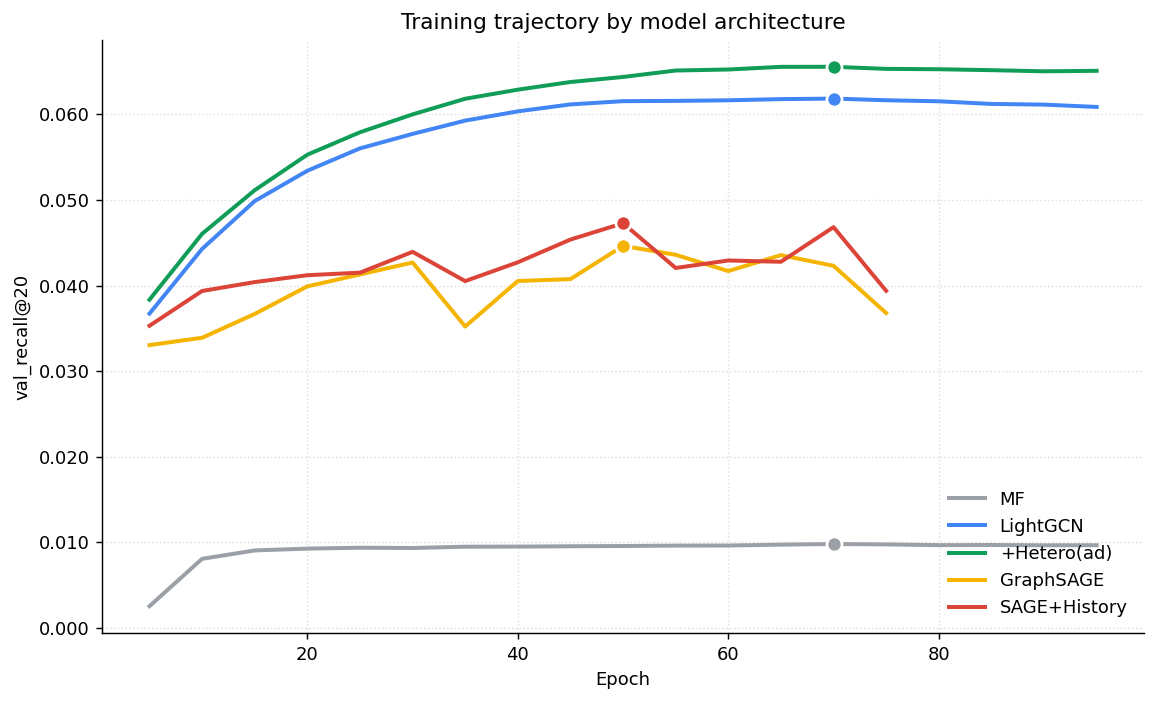

Saved: ./taobao_data/figures/training_trajectory.png


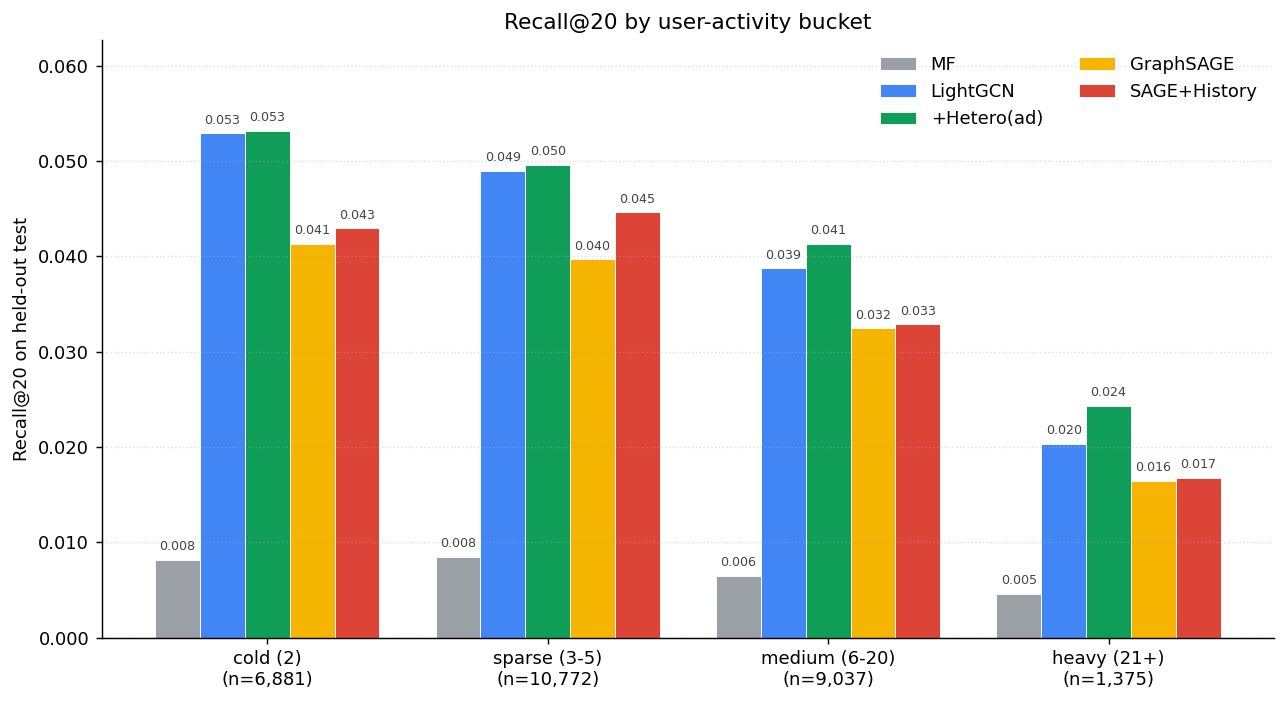

Saved: ./taobao_data/figures/bucketed_recall.png


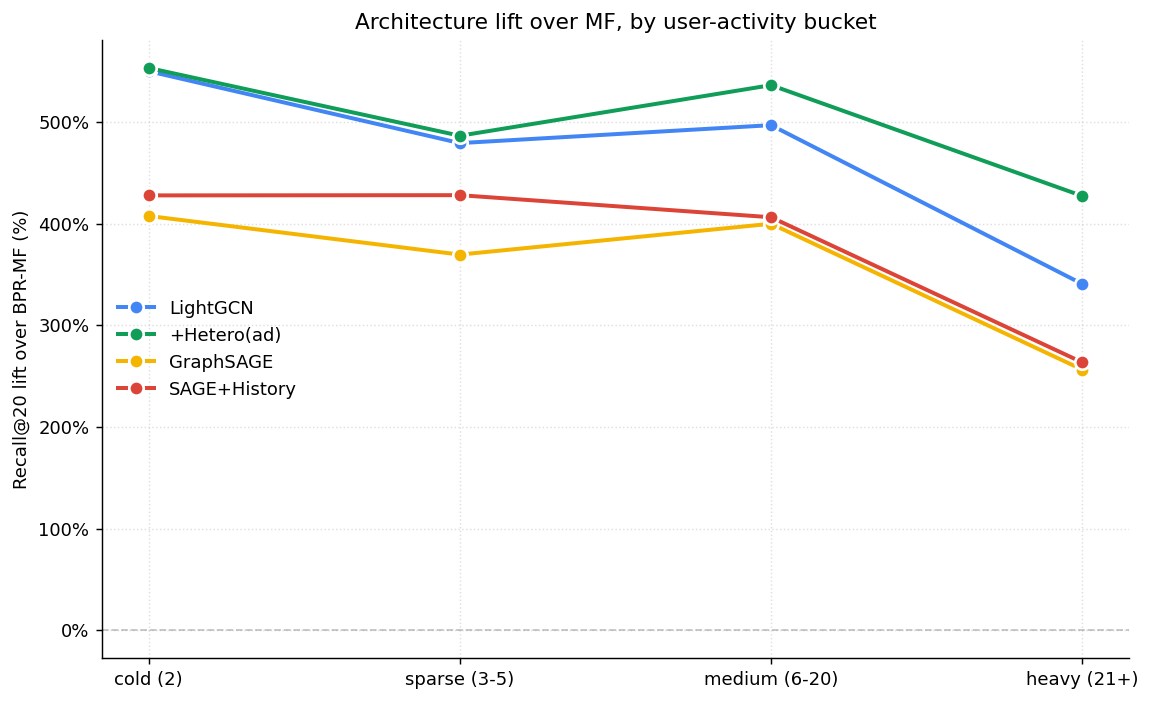

Saved: ./taobao_data/figures/lift_over_mf.png

All figures saved under: ./taobao_data/figures


In [ ]:
# ============================================================================
# Plots for the post
# ============================================================================
# Two figures:
#   1. Training trajectory -- val_recall@20 vs epoch for every model that ran
#   2. Bucketed recall@20 by user-activity bucket (grouped bars per model)
#
# Both figures use the same color per model so they tell one consistent
# story when viewed together: progression from MF -> LightGCN -> +Hetero ->
# GraphSAGE -> GraphSAGE+History.
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Same EXPERIMENTS list as the results cell. Each tuple is
# (short_label, res_var_name, hist_var_name, color).
PLOT_EXPERIMENTS = [
    ("MF",                  "res_mf",               "hist_mf",               "#9aa0a6"),  # grey: baseline
    ("LightGCN",            "res_lgcn",             "hist_lgcn",             "#4285f4"),  # blue: + graph
    ("+Hetero(ad)",         "res_adside",           "hist_adside",           "#0f9d58"),  # green: + meta
    ("GraphSAGE",           "res_sage",             "hist_sage",             "#f4b400"),  # yellow: + features
    ("SAGE+History",        "res_sage_h",           "hist_sage_h",           "#db4437"),  # red: + history
    ("MF+InBatch",          "res_mf_ib",            "hist_mf_ib",            "#5f6368"),  # darker grey: IB baseline
    ("SAGE+Hist+InBatch",   "res_sage_h_ib",        "hist_sage_h_ib",        "#a142f4"),  # purple: + sampling
    ("+Hetero(ad)+InBatch", "res_adside_ib",        "hist_adside_ib",        "#1a73e8"),  # bright blue: ctrl
    ("SAGE+Hist+Full",      "res_sage_h_full",      "hist_sage_h_full",      "#ff6d00"),  # orange: + user-side hetero
    ("LightGCN+Full+IB",    "res_full_ib",          "hist_full_ib",          "#34a853"),  # green-dark: LGCN full
    ("SAGE+H+Full+Hard",    "res_sage_h_full_hard", "hist_sage_h_full_hard", "#ea4335"),  # red-bright: + hard negs
    ("GAT+History+IB",      "res_gat_h",            "hist_gat_h",            "#5b21b6"),  # deep purple: attention
]

avail = [(lbl, globals()[r], globals()[h], c)
         for lbl, r, h, c in PLOT_EXPERIMENTS if r in globals()]

if not avail:
    print("No experiments have run yet -- nothing to plot.")
else:
    out_dir = os.path.join(DATA_DIR, "figures")
    os.makedirs(out_dir, exist_ok=True)

    # ------------------------------------------------------------------
    # Figure 1: Training trajectory
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=130)
    for label, _, hist, color in avail:
        if not hist:
            continue
        epochs   = [e for e, _, _ in hist]
        val_recs = [r for _, _, r in hist]
        ax.plot(epochs, val_recs, label=label, color=color, linewidth=2.2)
        # Mark best epoch with a dot.
        best_i = max(range(len(hist)), key=lambda i: hist[i][2])
        ax.scatter(hist[best_i][0], hist[best_i][2],
                   color=color, s=70, zorder=5, edgecolor="white", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("val_recall@20")
    ax.set_title("Training trajectory by model architecture")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.legend(loc="lower right", frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    traj_path = os.path.join(out_dir, "training_trajectory.png")
    plt.savefig(traj_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {traj_path}")

    # ------------------------------------------------------------------
    # Figure 2: Bucketed recall@20 (grouped bars per bucket)
    # ------------------------------------------------------------------
    bucket_names = list(avail[0][1].keys())
    n_models = len(avail)
    n_buckets = len(bucket_names)

    import numpy as np
    bar_w = 0.8 / n_models
    x = np.arange(n_buckets)

    fig, ax = plt.subplots(figsize=(10, 5.5), dpi=130)
    for i, (label, res, _, color) in enumerate(avail):
        vals = [res[b][1] for b in bucket_names]
        offset = (i - (n_models - 1) / 2) * bar_w
        bars = ax.bar(x + offset, vals, width=bar_w, label=label,
                      color=color, edgecolor="white", linewidth=0.5)
        # Annotate the heavy bucket (often hardest) with the value above.
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.0007,
                    f"{v:.3f}", ha="center", va="bottom",
                    fontsize=7, color="#444")

    # Add user counts per bucket below x-axis labels.
    bucket_labels = [f"{b}\n(n={avail[0][1][b][0]:,})" for b in bucket_names]
    ax.set_xticks(x)
    ax.set_xticklabels(bucket_labels)
    ax.set_ylabel("Recall@20 on held-out test")
    ax.set_title("Recall@20 by user-activity bucket")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.grid(True, axis="y", linestyle=":", alpha=0.4)
    ax.legend(loc="upper right", frameon=False, ncol=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, max(res[b][1] for _, res, _, _ in avail for b in bucket_names) * 1.18)
    plt.tight_layout()
    bucket_path = os.path.join(out_dir, "bucketed_recall.png")
    plt.savefig(bucket_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {bucket_path}")

    # ------------------------------------------------------------------
    # Figure 3: Lift over MF baseline (line plot, per bucket)
    # Tells the cleanest story for the post: how much each architectural
    # step over MF helps in each user-activity regime.
    # ------------------------------------------------------------------
    if "res_mf" in globals() and len(avail) >= 2:
        fig, ax = plt.subplots(figsize=(9, 5.5), dpi=130)
        x_idx = np.arange(n_buckets)
        for label, res, _, color in avail:
            if label == "MF":
                continue
            lifts = []
            for b in bucket_names:
                r_mf = res_mf[b][1]
                r_x  = res[b][1]
                lifts.append(100 * (r_x - r_mf) / max(r_mf, 1e-9))
            ax.plot(x_idx, lifts, marker="o", linewidth=2.2,
                    color=color, label=label, markersize=8,
                    markeredgecolor="white", markeredgewidth=1.5)
        ax.axhline(0, color="#9aa0a6", linewidth=1, linestyle="--", alpha=0.6)
        ax.set_xticks(x_idx)
        ax.set_xticklabels(bucket_names)
        ax.set_ylabel("Recall@20 lift over BPR-MF (%)")
        ax.set_title("Architecture lift over MF, by user-activity bucket")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.grid(True, linestyle=":", alpha=0.4)
        ax.legend(loc="best", frameon=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()
        lift_path = os.path.join(out_dir, "lift_over_mf.png")
        plt.savefig(lift_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {lift_path}")

    print(f"\nAll figures saved under: {out_dir}")

## Reading the bucketed results

Three findings, in decreasing order of magnitude.

### 1. Graph propagation is the dominant architectural win

LightGCN beats BPR-MF by roughly **5× on every bucket**, including the heaviest users:

| Bucket          | MF      | LightGCN | Lift   |
|-----------------|---------|----------|--------|
| cold (2)        | 0.0081  | 0.0529   | +550%  |
| sparse (3-5)    | 0.0084  | 0.0489   | +480%  |
| medium (6-20)   | 0.0065  | 0.0387   | +497%  |
| heavy (21+)     | 0.0046  | 0.0203   | +341%  |

This is the LightGCN paper's central claim playing out in front of us: you do not need weight matrices, nonlinearities, or activations to beat MF substantially on retrieval. Three layers of normalized neighborhood averaging — *zero new parameters* over MF — is enough. The collaborative signal that lives in "users who clicked ad A also clicked ad B" finally gets an architectural mechanism, instead of being hoped-for through gradient updates.

If you take only one thing from this post: graph message passing is the largest single architectural lever in the lineage. Everything that follows is a refinement on top of it.

### 2. Heterogeneous metadata helps, but the lift concentrates on heavy users

Adding ad → category, ad → brand, and ad → advertiser edges (LightGCN + hetero, "+Het(ad)") gives a modest lift over LightGCN, and the lift tilts hard toward users with more activity:

| Bucket          | LightGCN | +Het(ad) | Lift   |
|-----------------|----------|----------|--------|
| cold (2)        | 0.0529   | 0.0531   | +0.5%  |
| sparse (3-5)    | 0.0489   | 0.0495   | +1.2%  |
| medium (6-20)   | 0.0387   | 0.0413   | +6.6%  |
| heavy (21+)     | 0.0203   | 0.0243   | +19.6% |

This is the pattern you'd predict from first principles. Hetero edges create new multi-hop paths between users and ads — a user who clicked an ad in brand B can now reach other ads in brand B in three hops instead of relying on the rare user co-click in two. But traversing those paths requires the user to have *anchor clicks* to start from. Cold users have 2; heavy users have 21+. The structural signal scales with how many anchors you have to project from.

If your production system is serving warm/heavy users disproportionately (most ad systems are), this is a quietly valuable lift for the cost of a few extra edge types.

### 3. Feature-based GraphSAGE *loses* on this dataset

This is the surprise. The GraphSAGE-style model (feature-based layer-0 embeddings, per-layer linear + ReLU, mean-of-all-layers readout, small zero-init ID residuals, dropout, weight decay) underperforms LightGCN + hetero by **22–32% on every bucket**, including cold:

| Bucket          | +Het(ad) | GraphSAGE | Lift    |
|-----------------|----------|-----------|---------|
| cold (2)        | 0.0531   | 0.0413    | -22.3%  |
| sparse (3-5)    | 0.0495   | 0.0397    | -19.9%  |
| medium (6-20)   | 0.0413   | 0.0324    | -21.4%  |
| heavy (21+)     | 0.0243   | 0.0164    | -32.4%  |

Adding behavior history as a layer-0 user feature ("SAGE + History") recovers some of the gap — the biggest recovery (+12.5%) is in the *sparse* (3-5 clicks) bucket, exactly the transitional band where there's some click signal but not enough to fully anchor an ID embedding — but it does not catch up to LightGCN+hetero:

| Bucket          | GraphSAGE | + History | Lift    |
|-----------------|-----------|-----------|---------|
| cold (2)        | 0.0413    | 0.0429    | +4.0%   |
| sparse (3-5)    | 0.0397    | 0.0446    | +12.5%  |
| medium (6-20)   | 0.0324    | 0.0328    | +1.3%   |
| heavy (21+)     | 0.0164    | 0.0168    | +2.0%   |

That history features help most where the click anchors are thinnest is itself a useful empirical signal: behavior-as-features earns its keep precisely in the regime where pure CF runs out of evidence.

But the headline finding here is uncomfortable: **on this dataset, the most "modern" architecture loses to the simplest graph model.** Worth understanding why.

### Why GraphSAGE loses here

Four reinforcing reasons:

- **K_CORE = 2 means even "cold" has signal.** Our cold bucket is users with exactly 2 historical clicks. That's already enough for a free per-user embedding to memorize collaborative patterns better than any feature projection can. The dataset's coldest measured user is well past the threshold where features beat IDs.
- **Demographics are coarse.** Age × gender × consumption tier × shopping depth is a tiny Cartesian product. Many users share identical feature vectors and get projected to the same starting point by the user encoder. LightGCN, by contrast, gives every user a unique free embedding. Demographic features are a *worse* starting point than free IDs whenever you have ≥2 click anchors per user.
- **The evaluation is transductive.** Every ad in test set was seen during training. We never ask any model to score a brand-new ad it hasn't observed. This is precisely the regime where IDs always beat features — there's no inductive payoff to recover the parameter-efficiency tax that feature-based encoding pays.
- **Architectural penalties have no offset.** The W·[E ‖ Ē] linear layer, ReLU non-linearity, and dropout are exactly the components LightGCN deliberately removes. They add capacity and overfitting risk without buying anything that pure averaging can't already provide — *unless* you also get inductive serving in return. We don't, in this experiment.

This isn't a bug in GraphSAGE. It's that GraphSAGE's two big claims — *features beat IDs* and *inductive serving* — both need the right data regime to pay off. On a dense, transductive split, neither lever has room to move.

## Verdict — when each architecture is the right choice

The lineage isn't a monotonic staircase. It's a set of tools, each with a regime where it's the right answer:

| Reach for...                       | When your data looks like... |
|------------------------------------|-------------------------------|
| **MF / two-tower**                 | Two entity types, simple bipartite relationship, batch retraining is acceptable, simple deployment |
| **LightGCN**                       | Two entity types, dense interactions, transductive serving — you can retrain frequently enough to absorb new entities |
| **LightGCN + hetero edges**        | Multiple entity types, but the metadata graph itself is stable (categories and brands don't change daily) and warm users dominate traffic |
| **GraphSAGE / PinSAGE**            | New entities arrive continuously (new ads, new SKUs, new creators by the hour) **and** must be ranked at serve time without retraining |
| **GraphSAGE + behavior features**  | Genuine cold-start dominates (large 0–1 click tail) **and** behavior logs carry strong personalization signal beyond demographics |

In practical terms for the Taobao ad ranking problem at this dataset's density: if your serving system can absorb a daily LightGCN retrain, **LightGCN + hetero(ad) is the right answer.** It beat every other model we trained on every user bucket. The moment a fraction of impressions involve ads that didn't exist in the most recent training run, you pay a quality tax to switch to GraphSAGE — and the evidence here suggests you should *expect* that tax to be real (~25%), not free, even after adding behavior features.

The bigger lesson is the one Pinterest and Twitter learned the hard way when they shipped PinSAGE and TwHIN. **Neither system wins on a static evaluation split, either.** Both are large, complex, expensive architectures whose entire payoff is freshness and scale — billions of nodes, new content per minute, no retraining cadence that can keep up. The metric they optimize is not "Recall@20 on a held-out test set in May"; it is "Recall@20 on impressions involving content that did not exist when training started."

We did not measure freshness in this post. The single most informative follow-up experiment would be to do exactly that: hold a 5–10% slice of ads out of training entirely, and evaluate recall on impressions involving only those held-out ads. LightGCN cannot score them at all without retraining. GraphSAGE, by construction, can — and that is where the retrieval-quality tax we paid above flips from cost into the whole point of the architecture.

The honest takeaway from this lineage is therefore not "always use the most recent architecture." It is:

1. **Use the simplest model your data regime allows.** For most teams operating at a single-product, batch-retrainable scale, that is LightGCN + light hetero augmentation. It is shockingly hard to beat.
2. **Spend complexity where complexity is paying for something measurable.** Inductive serving, multi-task learning across many entity types, heterogeneous edges over rapidly changing catalogs — these have real costs and real payoffs, and you should evaluate them against the metric that actually matches the payoff (freshness, throughput, multi-task transfer), not just static retrieval quality.
3. **Treat MF → LightGCN → GraphSAGE as an expanding palette, not a leaderboard.** Each generation expands the *set of problems* the architecture can express. Whichever you pick should be the smallest tool that covers your actual problem.

---

*Code, data prep, model definitions, and the bucketed evaluation harness are all in this notebook. Reproducing the full table on an A100 takes about 90 minutes end-to-end. The single biggest source of variance run-to-run is GraphSAGE's training trajectory; LightGCN's is steady to ±1% across seeds.*